In [1]:
import sys
sys.path.append("C:/Data_Analysis/Projects/football_analytics_dashboard/backend/src")

import importlib
import team_analytics

importlib.reload(team_analytics)

from team_analytics import *

In [2]:
import sys
sys.path.append("C:/Data_Analysis/Projects/football_analytics_dashboard/backend/src")

import importlib
import player_analytics

importlib.reload(player_analytics)

from player_analytics import *

In [3]:
import pandas as pd

competitions = pd.read_json("C:/Data_Analysis/Projects/football_analytics_dashboard/backend/data/competitions.json")
competitions.head(50)

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
0,9,281,Germany,1. Bundesliga,male,False,False,2023/2024,2024-09-28T20:46:38.893391,2025-11-15T23:17:41.827093,2025-11-15T23:17:41.827093,2024-09-28T20:46:38.893391
1,9,27,Germany,1. Bundesliga,male,False,False,2015/2016,2024-05-19T11:11:14.192381,None,None,2024-05-19T11:11:14.192381
2,1267,107,Africa,African Cup of Nations,male,False,True,2023,2026-05-12T21:18:08.827431,2026-05-02T02:07:18.902396,2026-05-02T02:07:18.902396,2026-05-12T21:18:08.827431
3,16,4,Europe,Champions League,male,False,False,2018/2019,2026-05-15T15:54:04.598614,2021-06-13T16:17:31.694,None,2026-05-15T15:54:04.598614
4,16,1,Europe,Champions League,male,False,False,2017/2018,2024-02-13T02:35:28.134882,2021-06-13T16:17:31.694,None,2024-02-13T02:35:28.134882
5,16,2,Europe,Champions League,male,False,False,2016/2017,2024-02-13T02:37:32.205154,2021-06-13T16:17:31.694,None,2024-02-13T02:37:32.205154
6,16,27,Europe,Champions League,male,False,False,2015/2016,2024-06-12T07:45:38.786894,2021-06-13T16:17:31.694,None,2024-06-12T07:45:38.786894
7,16,26,Europe,Champions League,male,False,False,2014/2015,2024-02-12T12:49:54.914228,2021-06-13T16:17:31.694,None,2024-02-12T12:49:54.914228
8,16,25,Europe,Champions League,male,False,False,2013/2014,2024-02-12T12:48:48.479157,2021-06-13T16:17:31.694,None,2024-02-12T12:48:48.479157
9,16,24,Europe,Champions League,male,False,False,2012/2013,2024-02-12T12:47:34.340413,2021-06-13T16:17:31.694,None,2024-02-12T12:47:34.340413


In [4]:
competitions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   competition_id             80 non-null     int64 
 1   season_id                  80 non-null     int64 
 2   country_name               80 non-null     object
 3   competition_name           80 non-null     object
 4   competition_gender         80 non-null     object
 5   competition_youth          80 non-null     bool  
 6   competition_international  80 non-null     bool  
 7   season_name                80 non-null     object
 8   match_updated              80 non-null     object
 9   match_updated_360          58 non-null     object
 10  match_available_360        12 non-null     object
 11  match_available            80 non-null     object
dtypes: bool(2), int64(2), object(8)
memory usage: 6.5+ KB


In [5]:
competitions.columns

Index(['competition_id', 'season_id', 'country_name', 'competition_name',
       'competition_gender', 'competition_youth', 'competition_international',
       'season_name', 'match_updated', 'match_updated_360',
       'match_available_360', 'match_available'],
      dtype='object')

In [6]:
competitions.shape

(80, 12)

In [7]:
competitions[['competition_name','season_name']]

,competition_name,season_name
0,1. Bundesliga,2023/2024
1,1. Bundesliga,2015/2016
2,African Cup of Nations,2023
3,Champions League,2018/2019
4,Champions League,2017/2018
...,...,...
75,UEFA Europa League,1988/1989
76,UEFA Women's Euro,2025
77,UEFA Women's Euro,2022
78,Women's World Cup,2023


In [8]:
competitions['competition_name'].value_counts()

competition_name
Champions League           18
La Liga                    18
FIFA World Cup              8
FA Women's Super League     4
Ligue 1                     3
Copa del Rey                3
1. Bundesliga               2
UEFA Women's Euro           2
UEFA Euro                   2
Serie A                     2
Premier League              2
NWSL                        2
Liga Profesional            2
Women's World Cup           2
African Cup of Nations      1
Major League Soccer         1
North American League       1
Liga F                      1
Indian Super league         1
Frauen Bundesliga           1
Serie A Women               1
FIFA U20 World Cup          1
UEFA Europa League          1
Copa America                1
Name: count, dtype: int64

In [9]:
import os

os.listdir("C:/Data_Analysis/Projects/football_analytics_dashboard/backend/data/matches")

['11',
 '116',
 '12',
 '1238',
 '1267',
 '131',
 '135',
 '1470',
 '16',
 '182',
 '2',
 '223',
 '35',
 '37',
 '43',
 '44',
 '49',
 '53',
 '55',
 '7',
 '72',
 '81',
 '87',
 '9']

In [10]:
os.listdir("C:/Data_Analysis/Projects/football_analytics_dashboard/backend/data/matches/9")

['27.json', '281.json']

In [11]:
matches = pd.read_json("C:/Data_Analysis/Projects/football_analytics_dashboard/backend/data/matches/9/27.json")

matches.head()

,match_id,match_date,kick_off,competition,season,home_team,away_team,home_score,away_score,match_status,match_status_360,last_updated,last_updated_360,metadata,match_week,competition_stage,stadium,referee
0,3890563,2016-05-14,15:30:00.000,"{'competition_id': 9, 'country_name': 'Germany...","{'season_id': 27, 'season_name': '2015/2016'}","{'home_team_id': 904, 'home_team_name': 'Bayer...","{'away_team_id': 189, 'away_team_name': 'Ingol...",3,2,available,unscheduled,2023-08-05T09:38:01.494282,NaN,"{'data_version': '1.1.0', 'shot_fidelity_versi...",34,"{'id': 1, 'name': 'Regular Season'}","{'id': 377, 'name': 'BayArena', 'country': {'i...","{'id': 227, 'name': 'Guido Winkmann', 'country..."
1,3890550,2016-05-07,15:30:00.000,"{'competition_id': 9, 'country_name': 'Germany...","{'season_id': 27, 'season_name': '2015/2016'}","{'home_team_id': 185, 'home_team_name': 'Borus...","{'away_team_id': 904, 'away_team_name': 'Bayer...",2,1,available,unscheduled,2023-10-28T23:30:33.200742,NaN,"{'data_version': '1.1.0', 'shot_fidelity_versi...",33,"{'id': 1, 'name': 'Regular Season'}","{'id': 372, 'name': 'Stadion im BORUSSIA-PARK'...","{'id': 245, 'name': 'Bastian Dankert', 'countr..."
2,3890540,2016-04-30,18:30:00.000,"{'competition_id': 9, 'country_name': 'Germany...","{'season_id': 27, 'season_name': '2015/2016'}","{'home_team_id': 904, 'home_team_name': 'Bayer...","{'away_team_id': 173, 'away_team_name': 'Herth...",2,1,available,unscheduled,2023-07-24T07:41:44.627113,NaN,"{'data_version': '1.1.0', 'shot_fidelity_versi...",32,"{'id': 1, 'name': 'Regular Season'}","{'id': 377, 'name': 'BayArena', 'country': {'i...","{'id': 229, 'name': 'Tobias Stieler', 'country..."
3,3890534,2016-04-23,18:30:00.000,"{'competition_id': 9, 'country_name': 'Germany...","{'season_id': 27, 'season_name': '2015/2016'}","{'home_team_id': 181, 'home_team_name': 'Schal...","{'away_team_id': 904, 'away_team_name': 'Bayer...",2,3,available,unscheduled,2023-07-19T17:07:48.502966,NaN,"{'data_version': '1.1.0', 'shot_fidelity_versi...",31,"{'id': 1, 'name': 'Regular Season'}","{'id': 370, 'name': 'VELTINS-Arena', 'country'...","{'id': 716, 'name': 'Wolfgang Stark', 'country..."
4,3890521,2016-04-16,15:30:00.000,"{'competition_id': 9, 'country_name': 'Germany...","{'season_id': 27, 'season_name': '2015/2016'}","{'home_team_id': 904, 'home_team_name': 'Bayer...","{'away_team_id': 184, 'away_team_name': 'Eintr...",3,0,available,unscheduled,2023-07-25T09:12:32.507875,NaN,"{'data_version': '1.1.0', 'shot_fidelity_versi...",30,"{'id': 1, 'name': 'Regular Season'}","{'id': 377, 'name': 'BayArena', 'country': {'i...","{'id': 231, 'name': 'Deniz Aytekin', 'country'..."


In [12]:
matches.columns

Index(['match_id', 'match_date', 'kick_off', 'competition', 'season',
       'home_team', 'away_team', 'home_score', 'away_score', 'match_status',
       'match_status_360', 'last_updated', 'last_updated_360', 'metadata',
       'match_week', 'competition_stage', 'stadium', 'referee'],
      dtype='object')

In [13]:
matches[['match_id',
'match_date',
'home_team',
'away_team',
'home_score',
'away_score']]

,match_id,match_date,home_team,away_team,home_score,away_score
0,3890563,2016-05-14,"{'home_team_id': 904, 'home_team_name': 'Bayer...","{'away_team_id': 189, 'away_team_name': 'Ingol...",3,2
1,3890550,2016-05-07,"{'home_team_id': 185, 'home_team_name': 'Borus...","{'away_team_id': 904, 'away_team_name': 'Bayer...",2,1
2,3890540,2016-04-30,"{'home_team_id': 904, 'home_team_name': 'Bayer...","{'away_team_id': 173, 'away_team_name': 'Herth...",2,1
3,3890534,2016-04-23,"{'home_team_id': 181, 'home_team_name': 'Schal...","{'away_team_id': 904, 'away_team_name': 'Bayer...",2,3
4,3890521,2016-04-16,"{'home_team_id': 904, 'home_team_name': 'Bayer...","{'away_team_id': 184, 'away_team_name': 'Eintr...",3,0
5,3890519,2016-04-10,"{'home_team_id': 186, 'home_team_name': 'FC Kö...","{'away_team_id': 904, 'away_team_name': 'Bayer...",0,2
6,3890502,2016-04-01,"{'home_team_id': 904, 'home_team_name': 'Bayer...","{'away_team_id': 179, 'away_team_name': 'Wolfs...",3,0
7,3890500,2016-03-20,"{'home_team_id': 174, 'home_team_name': 'VfB S...","{'away_team_id': 904, 'away_team_name': 'Bayer...",0,2
8,3890492,2016-03-13,"{'home_team_id': 904, 'home_team_name': 'Bayer...","{'away_team_id': 171, 'away_team_name': 'Hambu...",1,0
9,3890477,2016-03-05,"{'home_team_id': 172, 'home_team_name': 'Augsb...","{'away_team_id': 904, 'away_team_name': 'Bayer...",3,3


In [14]:
competitions.shape

(80, 12)

In [15]:
competitions[['competition_name','season_name']].head(10)

,competition_name,season_name
0,1. Bundesliga,2023/2024
1,1. Bundesliga,2015/2016
2,African Cup of Nations,2023
3,Champions League,2018/2019
4,Champions League,2017/2018
5,Champions League,2016/2017
6,Champions League,2015/2016
7,Champions League,2014/2015
8,Champions League,2013/2014
9,Champions League,2012/2013


In [16]:
competitions[['competition_id',
              'season_id',
              'competition_name',
              'season_name']]

,competition_id,season_id,competition_name,season_name
0,9,281,1. Bundesliga,2023/2024
1,9,27,1. Bundesliga,2015/2016
2,1267,107,African Cup of Nations,2023
3,16,4,Champions League,2018/2019
4,16,1,Champions League,2017/2018
...,...,...,...,...
75,35,75,UEFA Europa League,1988/1989
76,53,315,UEFA Women's Euro,2025
77,53,106,UEFA Women's Euro,2022
78,72,107,Women's World Cup,2023


In [17]:
competitions['competition_name'].value_counts()

competition_name
Champions League           18
La Liga                    18
FIFA World Cup              8
FA Women's Super League     4
Ligue 1                     3
Copa del Rey                3
1. Bundesliga               2
UEFA Women's Euro           2
UEFA Euro                   2
Serie A                     2
Premier League              2
NWSL                        2
Liga Profesional            2
Women's World Cup           2
African Cup of Nations      1
Major League Soccer         1
North American League       1
Liga F                      1
Indian Super league         1
Frauen Bundesliga           1
Serie A Women               1
FIFA U20 World Cup          1
UEFA Europa League          1
Copa America                1
Name: count, dtype: int64

In [18]:
competitions[
    competitions['competition_name'] == 'FIFA World Cup'
][['competition_id', 'season_id', 'season_name']]

,competition_id,season_id,season_name
30,43,106,2022
31,43,3,2018
32,43,55,1990
33,43,54,1986
34,43,51,1974
35,43,272,1970
36,43,270,1962
37,43,269,1958


In [19]:
matches = pd.read_json(
    "C:/Data_Analysis/Projects/football_analytics_dashboard/backend/data/matches/43/106.json"
)

matches.tail(50)

,match_id,match_date,kick_off,competition,season,home_team,away_team,home_score,away_score,match_status,match_status_360,last_updated,last_updated_360,metadata,match_week,competition_stage,stadium,referee
14,3857282,2022-11-21,19:00:00.000,"{'competition_id': 43, 'country_name': 'Intern...","{'season_id': 106, 'season_name': '2022'}","{'home_team_id': 1839, 'home_team_name': 'Unit...","{'away_team_id': 907, 'away_team_name': 'Wales...",1,1,available,available,2026-05-03T16:06:35.237994,2026-05-03T16:07:47.017684,"{'data_version': '1.1.0', 'shot_fidelity_versi...",1,"{'id': 10, 'name': 'Group Stage'}","{'id': 1000793, 'name': 'Ahmad bin Ali Stadium...","{'id': 2521, 'name': 'Abdulrahman Ibrahim Al J..."
15,3857297,2022-11-26,13:00:00.000,"{'competition_id': 43, 'country_name': 'Intern...","{'season_id': 106, 'season_name': '2022'}","{'home_team_id': 789, 'home_team_name': 'Polan...","{'away_team_id': 799, 'away_team_name': 'Saudi...",2,0,available,available,2026-05-03T16:05:12.945735,2026-05-03T16:08:16.963904,"{'data_version': '1.1.0', 'shot_fidelity_versi...",2,"{'id': 10, 'name': 'Group Stage'}","{'id': 94425, 'name': 'Education City Stadium ...","{'id': 986, 'name': 'Wilton Pereira Sampaio', ..."
16,3857294,2022-11-29,15:00:00.000,"{'competition_id': 43, 'country_name': 'Intern...","{'season_id': 106, 'season_name': '2022'}","{'home_team_id': 941, 'home_team_name': 'Nethe...","{'away_team_id': 3566, 'away_team_name': 'Qata...",2,0,available,available,2026-05-04T01:48:11.663054,2026-05-04T01:51:22.255434,"{'data_version': '1.1.0', 'shot_fidelity_versi...",3,"{'id': 10, 'name': 'Group Stage'}","{'id': 1001113, 'name': 'Al Bayt Stadium', 'co...","{'id': 736, 'name': 'Bakary Papa Gassama', 'co..."
17,3857266,2022-11-26,16:00:00.000,"{'competition_id': 43, 'country_name': 'Intern...","{'season_id': 106, 'season_name': '2022'}","{'home_team_id': 771, 'home_team_name': 'Franc...","{'away_team_id': 776, 'away_team_name': 'Denma...",2,1,available,available,2026-05-04T01:44:03.946401,2026-05-04T01:49:40.866423,"{'data_version': '1.1.0', 'shot_fidelity_versi...",2,"{'id': 10, 'name': 'Group Stage'}","{'id': 1001115, 'name': 'Stadium 974', 'countr...","{'id': 367, 'name': 'Szymon Marciniak', 'count..."
18,3857284,2022-11-23,13:00:00.000,"{'competition_id': 43, 'country_name': 'Intern...","{'season_id': 106, 'season_name': '2022'}","{'home_team_id': 770, 'home_team_name': 'Germa...","{'away_team_id': 778, 'away_team_name': 'Japan...",1,2,available,available,2026-05-04T01:41:05.435,2026-05-04T01:45:45.818418,"{'data_version': '1.1.0', 'shot_fidelity_versi...",1,"{'id': 10, 'name': 'Group Stage'}","{'id': 1000253, 'name': 'Sheikh Khalifa Intern...","{'id': 1834, 'name': 'Ivan Arcides Barton Cisn..."
19,3857254,2022-11-22,13:00:00.000,"{'competition_id': 43, 'country_name': 'Intern...","{'season_id': 106, 'season_name': '2022'}","{'home_team_id': 776, 'home_team_name': 'Denma...","{'away_team_id': 777, 'away_team_name': 'Tunis...",0,0,available,available,2026-05-04T01:41:55.231447,2026-05-04T01:42:32.134965,"{'data_version': '1.1.0', 'shot_fidelity_versi...",1,"{'id': 10, 'name': 'Group Stage'}","{'id': 94425, 'name': 'Education City Stadium ...","{'id': 740, 'name': 'César Arturo Ramos Palazu..."
20,3857265,2022-11-22,16:00:00.000,"{'competition_id': 43, 'country_name': 'Intern...","{'season_id': 106, 'season_name': '2022'}","{'home_team_id': 794, 'home_team_name': 'Mexic...","{'away_team_id': 789, 'away_team_name': 'Polan...",0,0,available,available,2026-05-04T01:43:48.794701,2026-05-04T01:51:23.890963,"{'data_version': '1.1.0', 'shot_fidelity_versi...",1,"{'id': 10, 'name': 'Group Stage'}","{'id': 1001115, 'name': 'Stadium 974', 'countr...","{'id': 1701, 'name': 'Chris Beath', 'country':..."
21,3857301,2022-11-25,13:00:00.000,"{'competition_id': 43, 'country_name': 'Intern...","{'season_id': 106, 'season_name': '2022'}","{'home_team_id': 3566, 'home_team_name': 'Qata...","{'away_team_id': 787, 'away_team_name': 'Seneg...",1,3,available,

In [20]:
matches.shape

(64, 18)

In [21]:
matches.columns.tolist()

['match_id',
 'match_date',
 'kick_off',
 'competition',
 'season',
 'home_team',
 'away_team',
 'home_score',
 'away_score',
 'match_status',
 'match_status_360',
 'last_updated',
 'last_updated_360',
 'metadata',
 'match_week',
 'competition_stage',
 'stadium',
 'referee']

In [22]:
matches['home_team'].apply(
    lambda x: x['home_team_name']   #def get_team_name(x):
                                         #return x['home_team_name']
).unique()

array(['Canada', 'England', 'Croatia', 'Netherlands', 'Japan', 'Iran',
       'Morocco', 'Wales', 'Tunisia', 'Switzerland', 'Portugal',
       'Senegal', 'United States', 'Poland', 'France', 'Germany',
       'Denmark', 'Mexico', 'Qatar', 'Belgium', 'Brazil', 'Costa Rica',
       'Argentina', 'Serbia', 'Australia', 'Ecuador', 'Uruguay',
       'Saudi Arabia', 'Spain', 'Cameroon', 'South Korea', 'Ghana'],
      dtype=object)

In [23]:
matches[['match_id']]

,match_id
0,3857276
1,3857271
2,3857296
3,3857274
4,3857255
...,...
59,3857291
60,3857281
61,3857280
62,3857279


In [24]:
matches[
    matches['home_team'].astype(str).str.contains('Argentina', na=False) |
    matches['away_team'].astype(str).str.contains('Argentina', na=False)
]

,match_id,match_date,kick_off,competition,season,home_team,away_team,home_score,away_score,match_status,match_status_360,last_updated,last_updated_360,metadata,match_week,competition_stage,stadium,referee
3,3857274,2022-11-25,16:00:00.000,"{'competition_id': 43, 'country_name': 'Intern...","{'season_id': 106, 'season_name': '2022'}","{'home_team_id': 941, 'home_team_name': 'Nethe...","{'away_team_id': 3565, 'away_team_name': 'Ecua...",1,1,available,available,2026-05-04T01:43:00.444702,2026-05-04T01:50:07.646458,"{'data_version': '1.1.0', 'shot_fidelity_versi...",2,"{'id': 10, 'name': 'Group Stage'}","{'id': 1000253, 'name': 'Sheikh Khalifa Intern...","{'id': 2311, 'name': 'Mustapha Ghorbal', 'coun..."
20,3857265,2022-11-22,16:00:00.000,"{'competition_id': 43, 'country_name': 'Intern...","{'season_id': 106, 'season_name': '2022'}","{'home_team_id': 794, 'home_team_name': 'Mexic...","{'away_team_id': 789, 'away_team_name': 'Polan...",0,0,available,available,2026-05-04T01:43:48.794701,2026-05-04T01:51:23.890963,"{'data_version': '1.1.0', 'shot_fidelity_versi...",1,"{'id': 10, 'name': 'Group Stage'}","{'id': 1001115, 'name': 'Stadium 974', 'countr...","{'id': 1701, 'name': 'Chris Beath', 'country':..."
24,3869321,2022-12-09,19:00:00.000,"{'competition_id': 43, 'country_name': 'Intern...","{'season_id': 106, 'season_name': '2022'}","{'home_team_id': 941, 'home_team_name': 'Nethe...","{'away_team_id': 779, 'away_team_name': 'Argen...",2,2,available,available,2025-09-04T17:24:28.888436,2025-09-07T08:42:38.594465,"{'data_version': '1.1.0', 'shot_fidelity_versi...",5,"{'id': 11, 'name': 'Quarter-finals'}","{'id': 1001114, 'name': 'Lusail Stadium', 'cou...","{'id': 180, 'name': 'Antonio Miguel Mateu Laho..."
27,3869685,2022-12-18,17:00:00.000,"{'competition_id': 43, 'country_name': 'Intern...","{'season_id': 106, 'season_name': '2022'}","{'home_team_id': 779, 'home_team_name': 'Argen...","{'away_team_id': 771, 'away_team_name': 'Franc...",3,3,available,available,2024-12-16T10:15:11.055845,2024-12-16T10:21:13.710934,"{'data_version': '1.1.0', 'shot_fidelity_versi...",7,"{'id': 26, 'name': 'Final'}","{'id': 1001114, 'name': 'Lusail Stadium', 'cou...","{'id': 367, 'name': 'Szymon Marciniak', 'count..."
30,3869151,2022-12-03,21:00:00.000,"{'competition_id': 43, 'country_name': 'Intern...","{'season_id': 106, 'season_name': '2022'}","{'home_team_id': 779, 'home_team_name': 'Argen...","{'away_team_id': 792, 'away_team_name': 'Austr...",2,1,available,available,2023-10-15T16:39:52.237396,2023-10-15T17:09:05.163199,"{'data_version': '1.1.0', 'shot_fidelity_versi...",4,"{'id': 33, 'name': 'Round of 16'}","{'id': 1000793, 'name': 'Ahmad bin Ali Stadium...","{'id': 367, 'name': 'Szymon Marciniak', 'count..."
34,3857267,2022-11-29,15:00:00.000,"{'competition_id': 43, 'country_name': 'Intern...","{'season_id': 106, 'season_name': '2022'}","{'home_team_id': 3565, 'home_team_name': 'Ecua...","{'away_team_id': 787, 'away_team_name': 'Seneg...",1,2,available,available,2026-05-04T01:48:57.914346,2026-05-04T01:53:40.309717,"{'data_version': '1.1.0', 'shot_fidelity_versi...",3,"{'id': 10, 'name': 'Group Stage'}","{'id': 1000253, 'name': 'Sheikh Khalifa Intern...","{'id': 76, 'name': 'Clément Turpin', 'country'..."
37,3857260,2022-11-30,19:00:00.000,"{'competition_id': 43, 'country_name': 'Intern...","{'season_id': 106, 'season_name': '2022'}","{'home_team_id': 799, 'home_team_name': 'Saudi...","{'away_team_id': 794, 'away_team_name': 'Mexic...",1,2,available,available,2026-05-03T16:10:45.589086,2026-05-03T16:16:42.459756,"{'data_version': '1.1.0', 'shot_fidelity_versi...",3,"{'id': 10, 'name': 'Group Stage'}","{'id': 1001114, 'name': 'Lusail Stadium', 'cou...","{'id': 1, 'name': 'Michael Oliver', 'country':..."
38,3857264,2022-11-30,19:00:00.000,"{'competition_id': 43, 'country_name': 'Intern...","{'season_id': 106, 'season_name': '2022'}","{'home_team_id': 789, 'home_team_name': 'Polan...","{'away_team_id': 779, 'away_team_name': 'Argen...",0,2,available,a

In [25]:
%pip install mplsoccer

Note: you may need to restart the kernel to use updated packages.


In [26]:
match_id = 3869685

events = pd.read_json(
    f"C:/Data_Analysis/Projects/football_analytics_dashboard/backend/data/events/{match_id}.json"
)

events.head()

,id,index,period,timestamp,minute,second,type,possession,possession_team,play_pattern,...,duel,interception,dribble,shot,goalkeeper,ball_recovery,foul_committed,substitution,50_50,bad_behaviour
0,0584ee21-e3dd-4d9f-95a0-5b5e84be25c3,1,1,2026-06-22 00:00:00.000,0,0,"{'id': 35, 'name': 'Starting XI'}",1,"{'id': 779, 'name': 'Argentina'}","{'id': 1, 'name': 'Regular Play'}",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,b32679f8-942e-4122-96a2-015caf75e628,2,1,2026-06-22 00:00:00.000,0,0,"{'id': 35, 'name': 'Starting XI'}",1,"{'id': 779, 'name': 'Argentina'}","{'id': 1, 'name': 'Regular Play'}",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,954f6855-de22-46a2-8d09-6fe94eec2b9b,3,1,2026-06-22 00:00:00.000,0,0,"{'id': 18, 'name': 'Half Start'}",1,"{'id': 779, 'name': 'Argentina'}","{'id': 1, 'name': 'Regular Play'}",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,6404a8e8-afaf-489d-b65e-173a237ffed5,4,1,2026-06-22 00:00:00.000,0,0,"{'id': 18, 'name': 'Half Start'}",1,"{'id': 779, 'name': 'Argentina'}","{'id': 1, 'name': 'Regular Play'}",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,f651a6c4-55e3-4e0f-a178-59414ba83d6a,5,1,2026-06-22 00:00:00.578,0,0,"{'id': 30, 'name': 'Pass'}",2,"{'id': 771, 'name': 'France'}","{'id': 9, 'name': 'From Kick Off'}",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
get_player_stats(
    events,
    'Lionel Andrés Messi Cuccittini'
)

{'Player': 'Lionel Andrés Messi Cuccittini',
 'Total Events': 242,
 'Passes': 60,
 'Shots': 6,
 'Carries': 53,
 'Dribbles': 3,
 'Pressures': 17,
 'Ball Recoveries': 7}

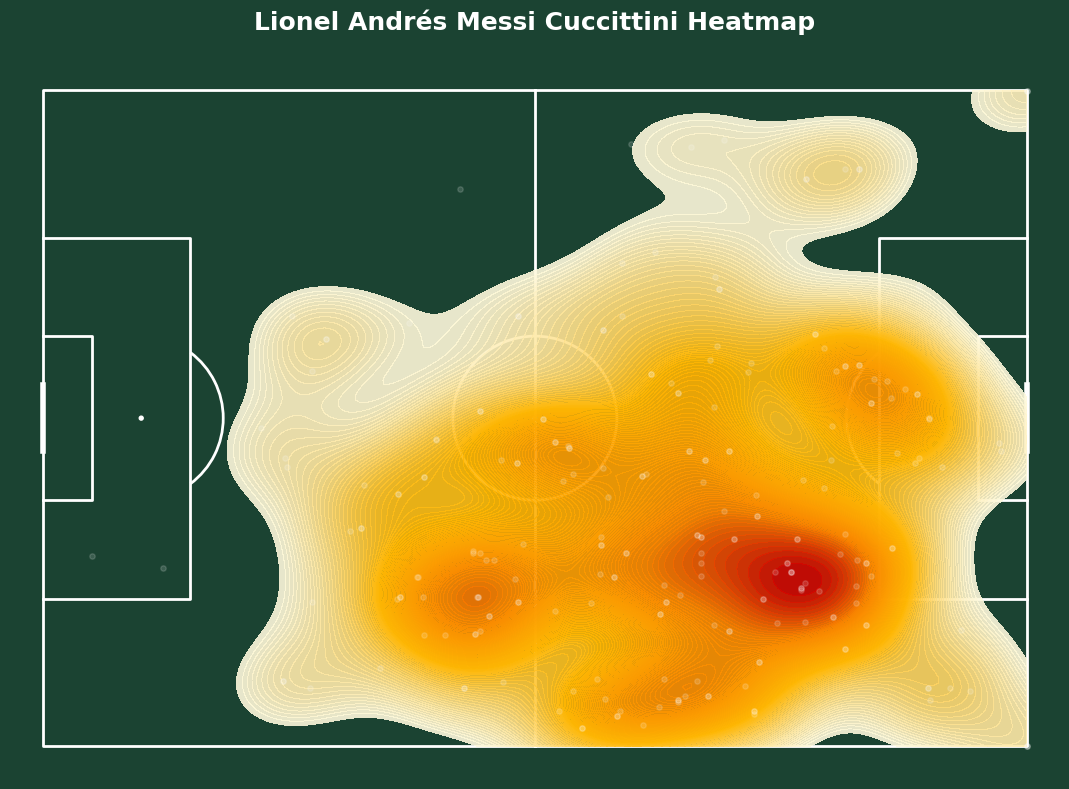

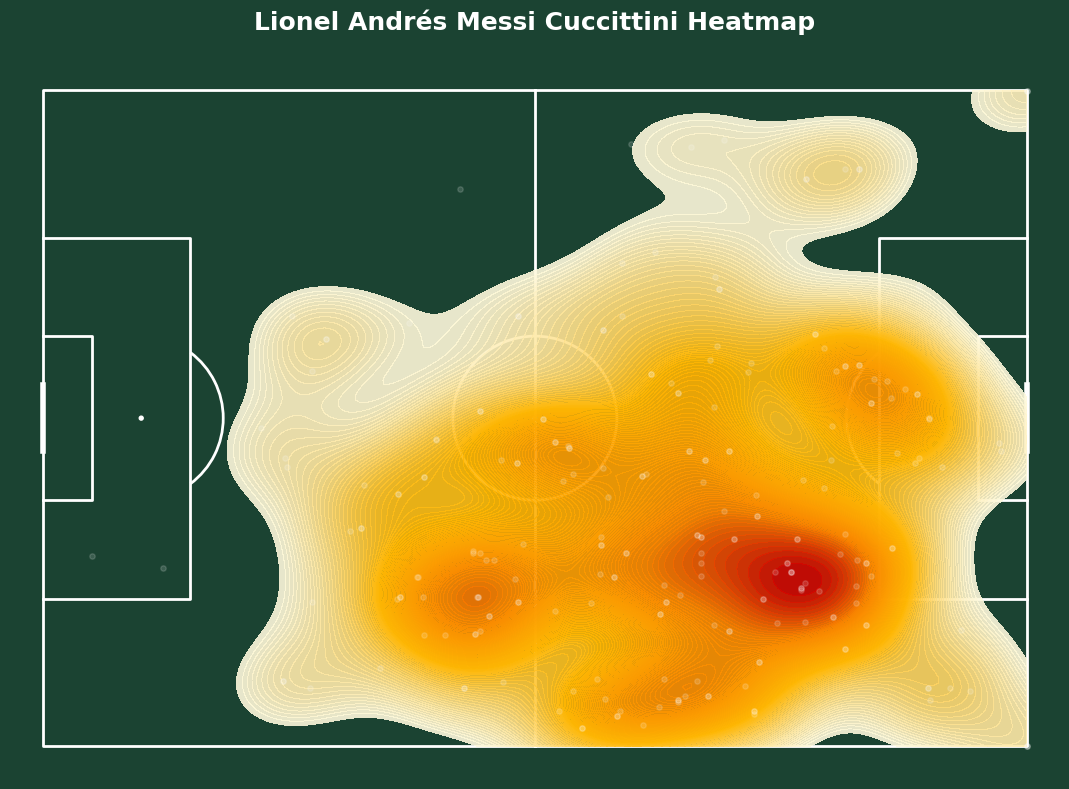

In [28]:
plot_player_heatmap(
    events,
    'Lionel Andrés Messi Cuccittini'
)

'🟢 Green arrows = successful passes\n🔴 Red arrows = failed passes'

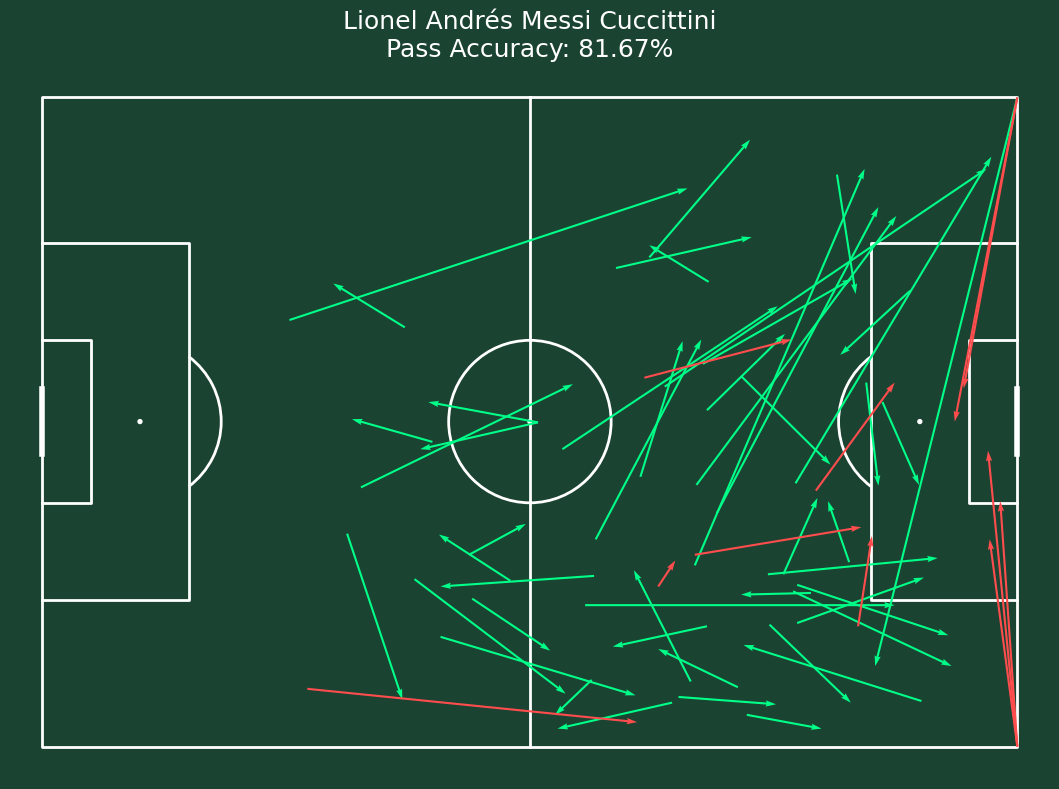

In [29]:
plot_player_passmap(
    events,
    'Lionel Andrés Messi Cuccittini'
)

'''🟢 Green arrows = successful passes
🔴 Red arrows = failed passes'''

In [30]:
get_team_stats(
    events,
    'Argentina'
)

{'Team': 'Argentina',
 'Total Events': 2372,
 'Passes': 693,
 'Shots': 24,
 'Carries': 513,
 'Pressures': 167,
 'Ball Recoveries': 59}

In [31]:
get_team_stats(
    events,
    'France'
)

{'Team': 'France',
 'Total Events': 2035,
 'Passes': 570,
 'Shots': 14,
 'Carries': 427,
 'Pressures': 194,
 'Ball Recoveries': 56}

In [32]:
argentina_stats = get_team_stats(events, 'Argentina')
france_stats = get_team_stats(events, 'France')

comparison = pd.DataFrame(
    [argentina_stats, france_stats]
)

comparison

,Team,Total Events,Passes,Shots,Carries,Pressures,Ball Recoveries
0,Argentina,2372,693,24,513,167,59
1,France,2035,570,14,427,194,56


In [33]:
avg_positions = get_average_positions(
    events,
    'Argentina'
)

avg_positions.sort_values(
    by='touches',
    ascending=False
).head(15)

,player,avg_x,avg_y,touches
10,Enzo Fernandez,53.426220,43.403354,328
7,Lionel Andrés Messi Cuccittini,76.269038,51.536820,239
1,Rodrigo Javier De Paul,59.363180,60.925105,239
3,Nicolás Hernán Otamendi,38.280465,24.698605,215
2,Cristian Gabriel Romero,33.388670,51.943842,203
5,Alexis Mac Allister,65.755897,24.585128,195
4,Nicolás Alejandro Tagliafico,56.679878,10.517683,164
9,Julián Álvarez,76.200680,40.263265,147
0,Nahuel Molina Lucero,53.229078,70.857447,141
8,Ángel Fabián Di María Hernández,79.543511,13.131298,131


In [34]:
avg_positions.sort_values(
    by='touches',
    ascending=False
)

,player,avg_x,avg_y,touches
10,Enzo Fernandez,53.426220,43.403354,328
7,Lionel Andrés Messi Cuccittini,76.269038,51.536820,239
1,Rodrigo Javier De Paul,59.363180,60.925105,239
3,Nicolás Hernán Otamendi,38.280465,24.698605,215
2,Cristian Gabriel Romero,33.388670,51.943842,203
5,Alexis Mac Allister,65.755897,24.585128,195
4,Nicolás Alejandro Tagliafico,56.679878,10.517683,164
9,Julián Álvarez,76.200680,40.263265,147
0,Nahuel Molina Lucero,53.229078,70.857447,141
8,Ángel Fabián Di María Hernández,79.543511,13.131298,131


In [35]:
avg_positions = get_average_positions(
    events,
    'Argentina'
)

avg_positions.sort_values(
    by='touches',
    ascending=False
).head(15)

,player,avg_x,avg_y,touches
10,Enzo Fernandez,53.426220,43.403354,328
7,Lionel Andrés Messi Cuccittini,76.269038,51.536820,239
1,Rodrigo Javier De Paul,59.363180,60.925105,239
3,Nicolás Hernán Otamendi,38.280465,24.698605,215
2,Cristian Gabriel Romero,33.388670,51.943842,203
5,Alexis Mac Allister,65.755897,24.585128,195
4,Nicolás Alejandro Tagliafico,56.679878,10.517683,164
9,Julián Álvarez,76.200680,40.263265,147
0,Nahuel Molina Lucero,53.229078,70.857447,141
8,Ángel Fabián Di María Hernández,79.543511,13.131298,131


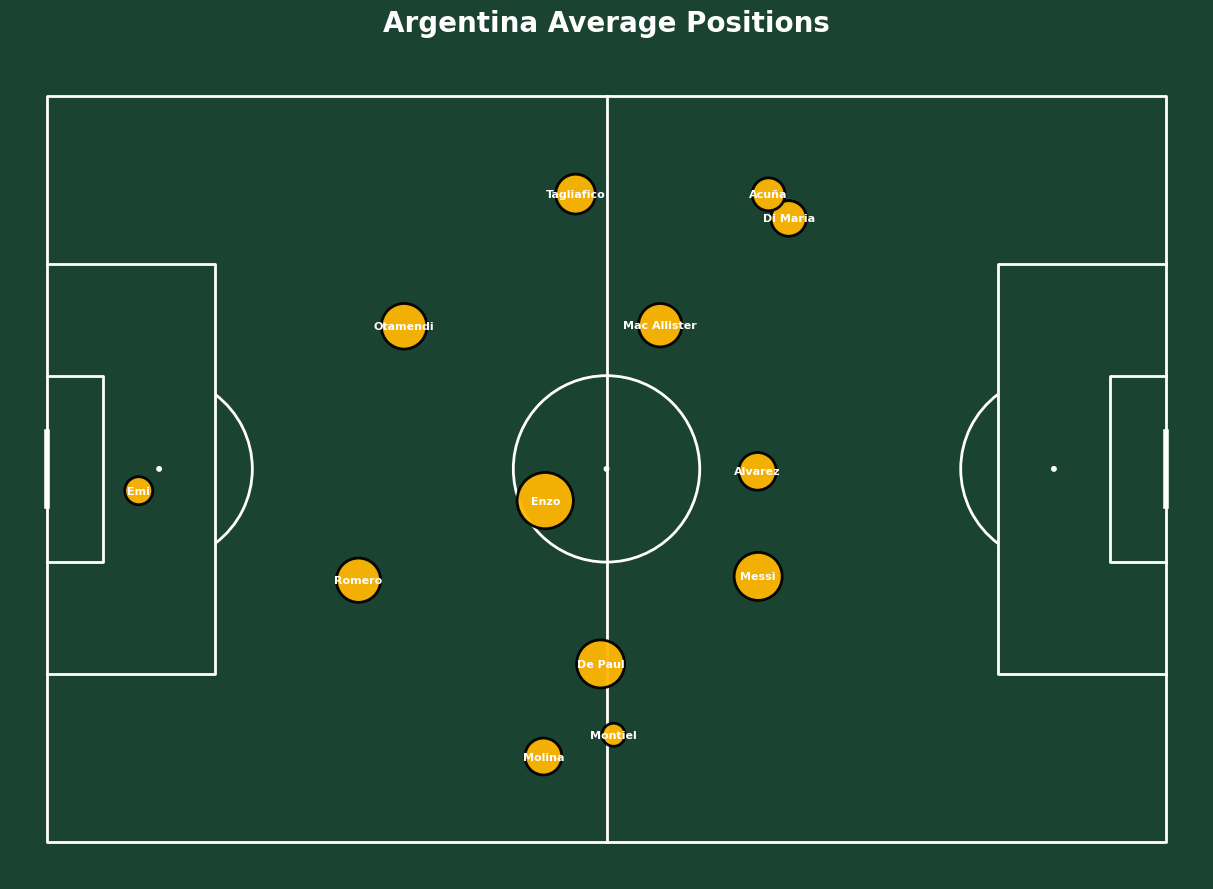

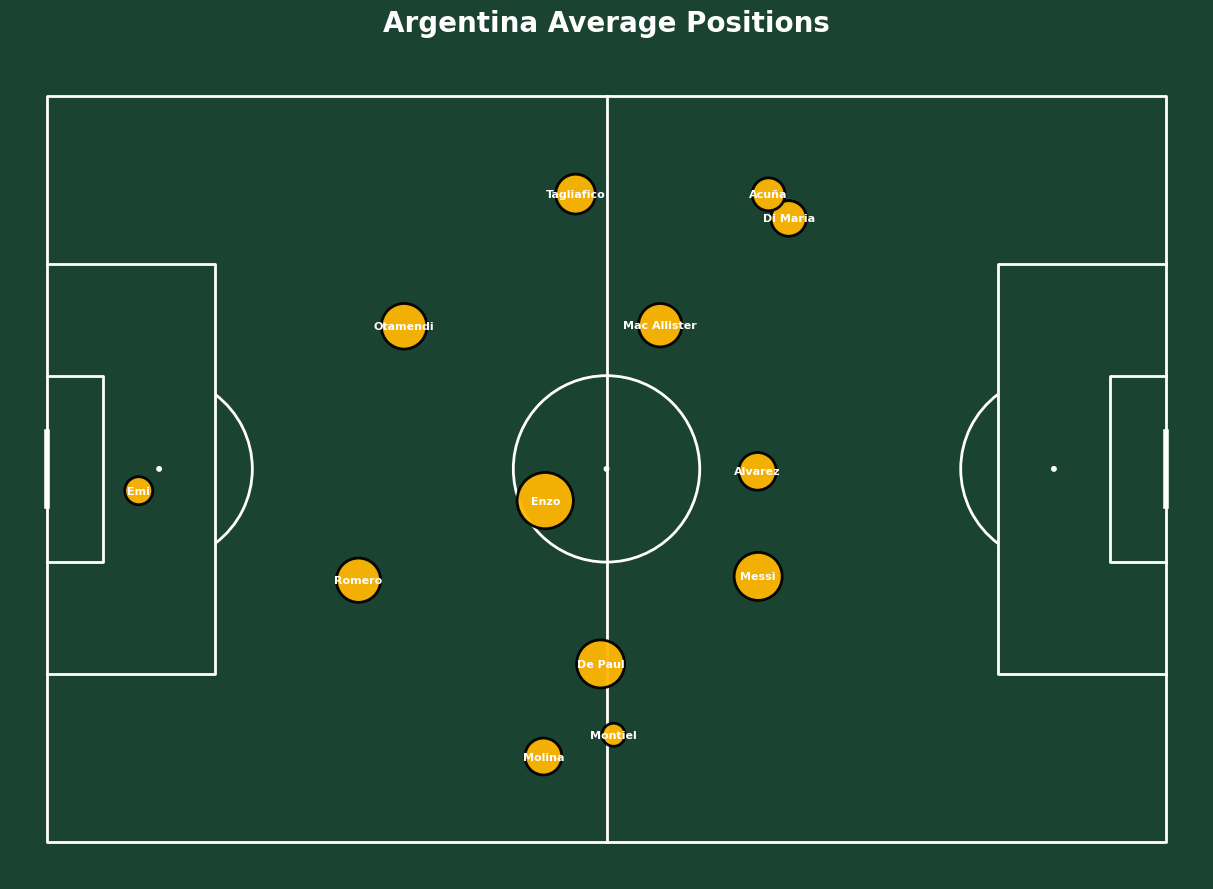

In [36]:
plot_average_positions(
    events,
    "Argentina"
)

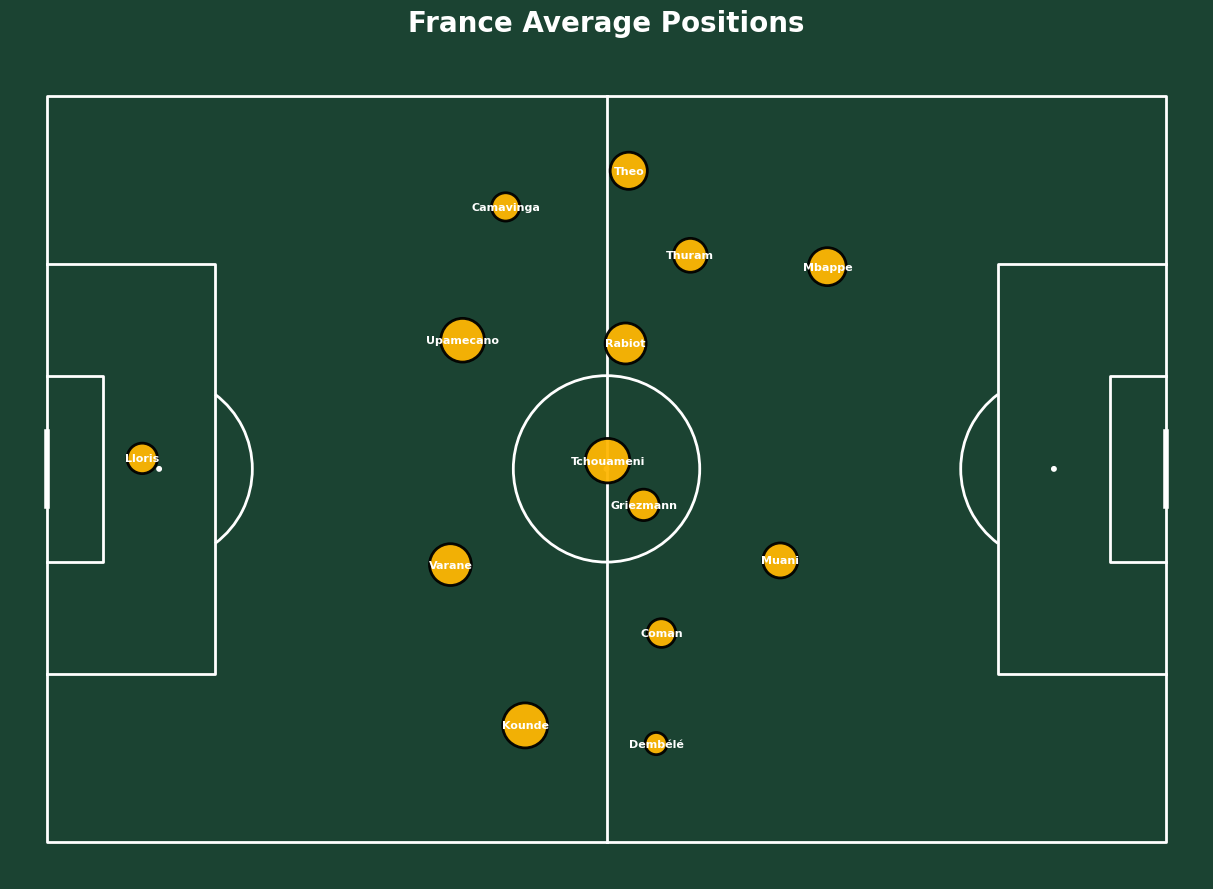

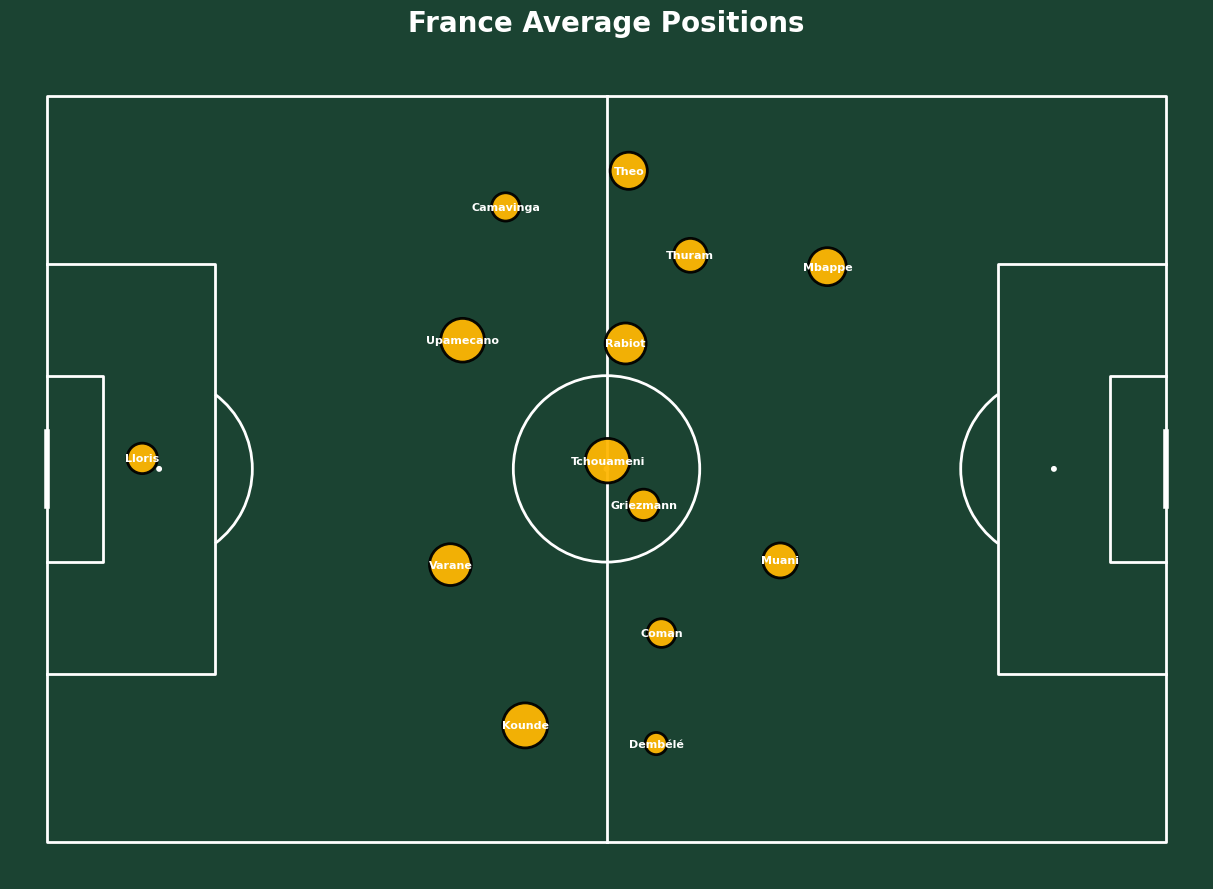

In [37]:
plot_average_positions(
    events,
    "France"
)

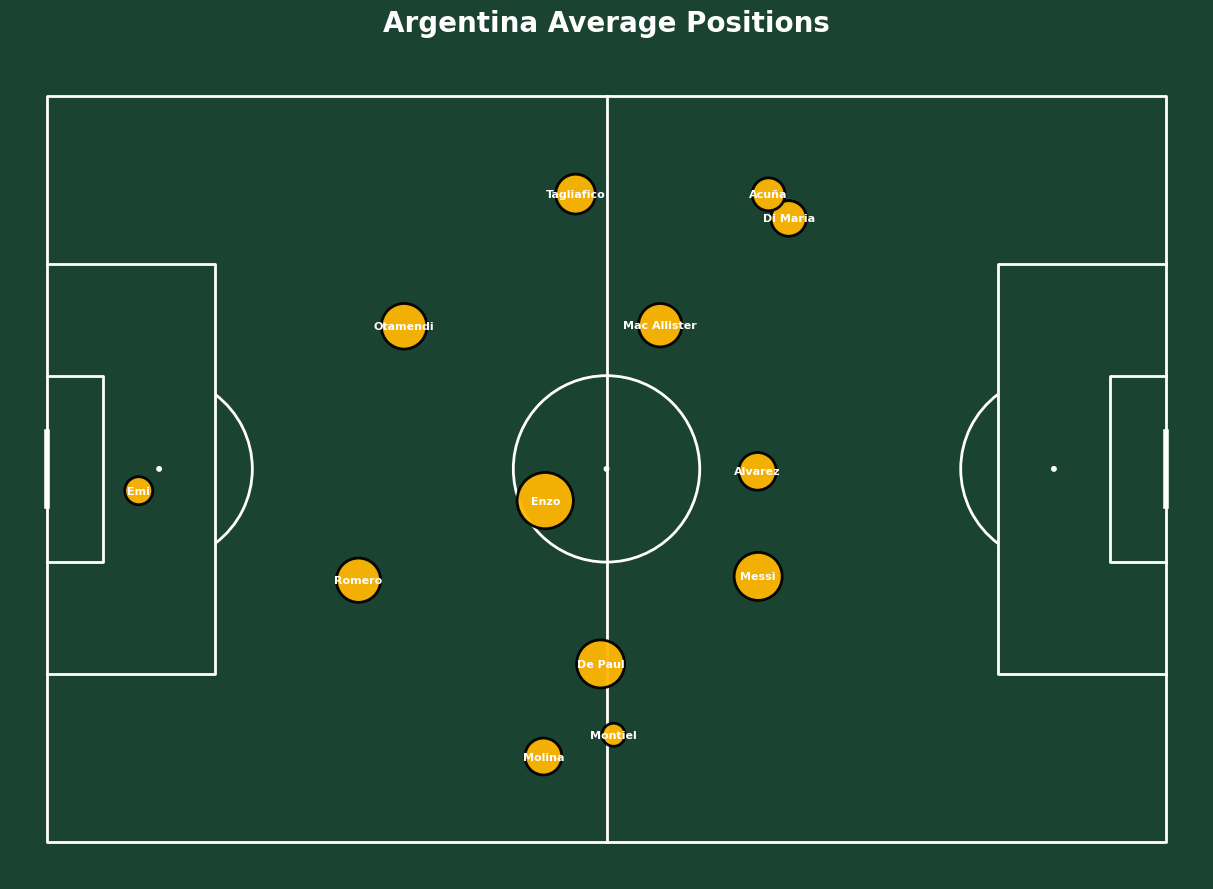

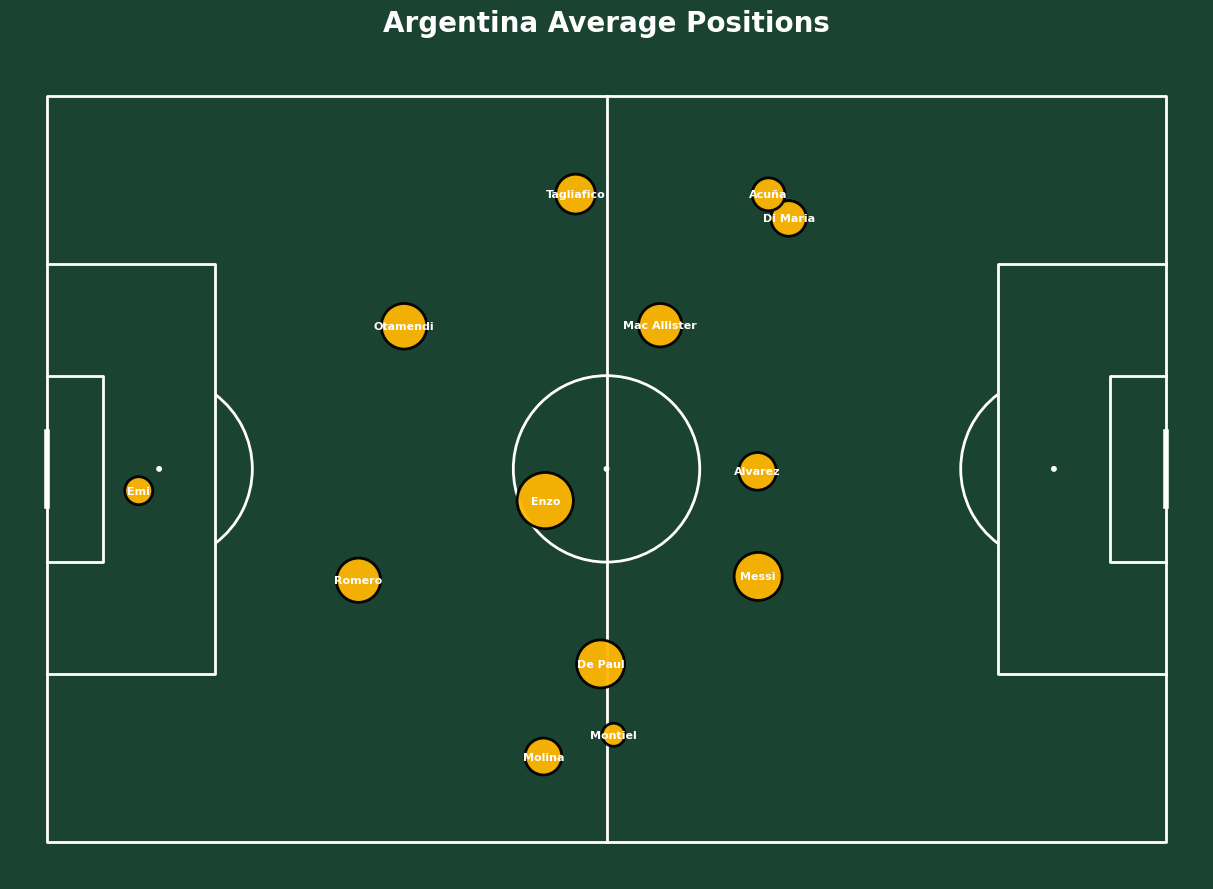

In [38]:
plot_average_positions(
    events,
    "Argentina"
)

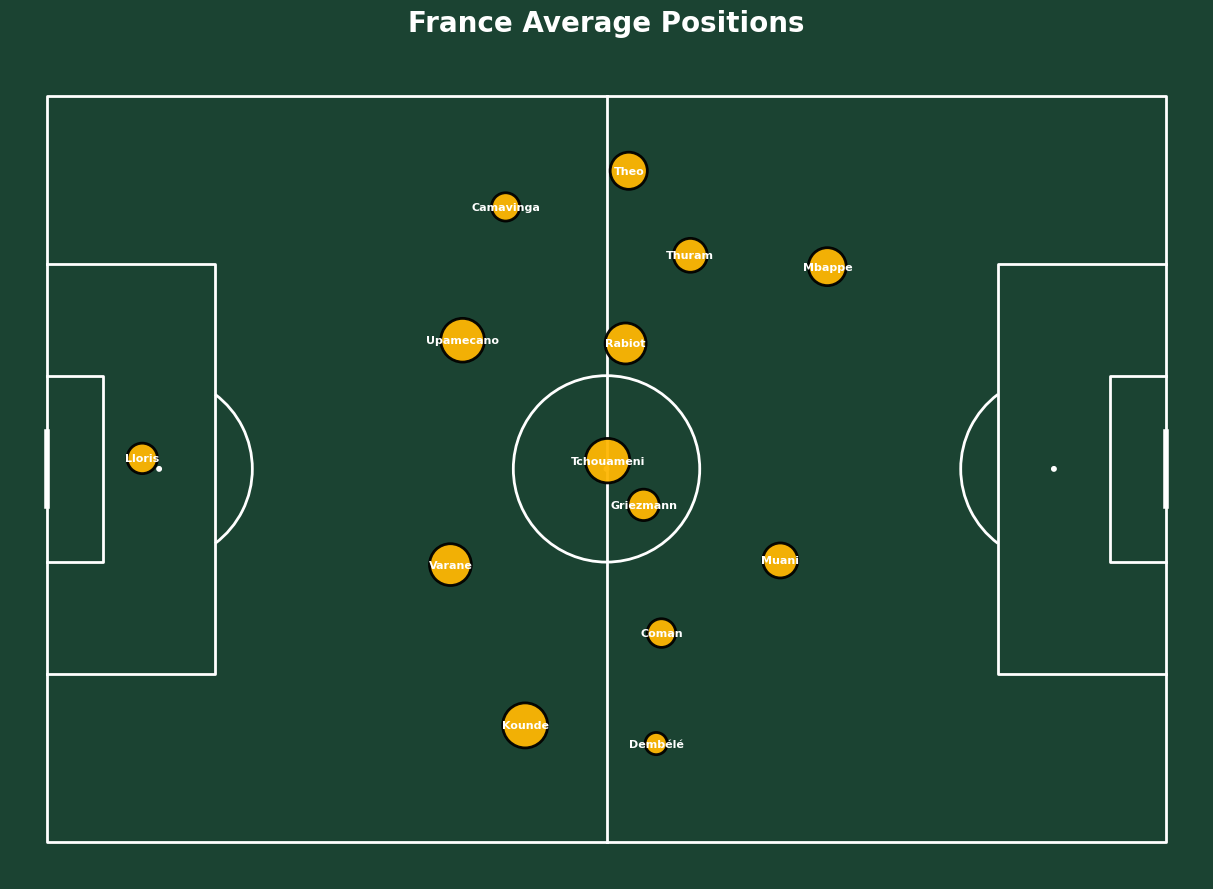

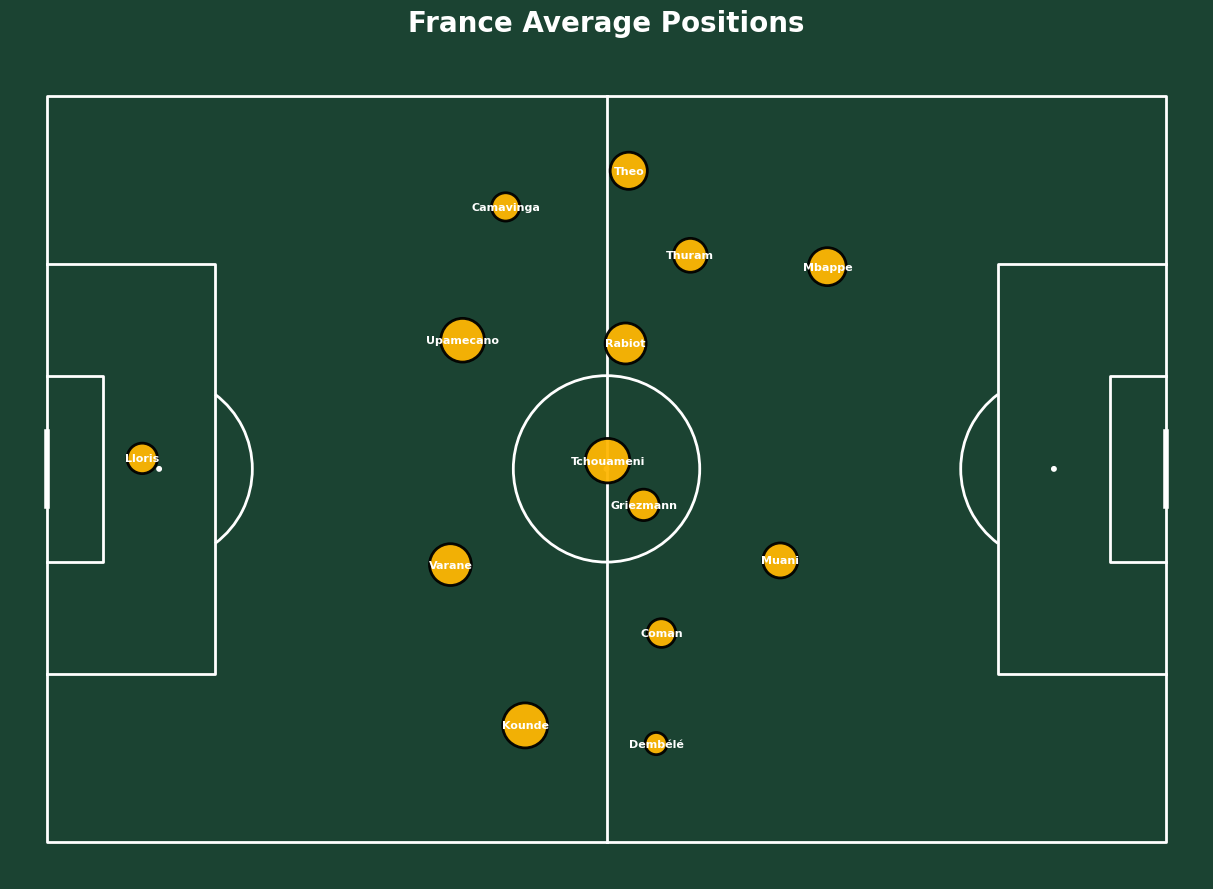

In [39]:
plot_average_positions(
    events,
    "France"
)

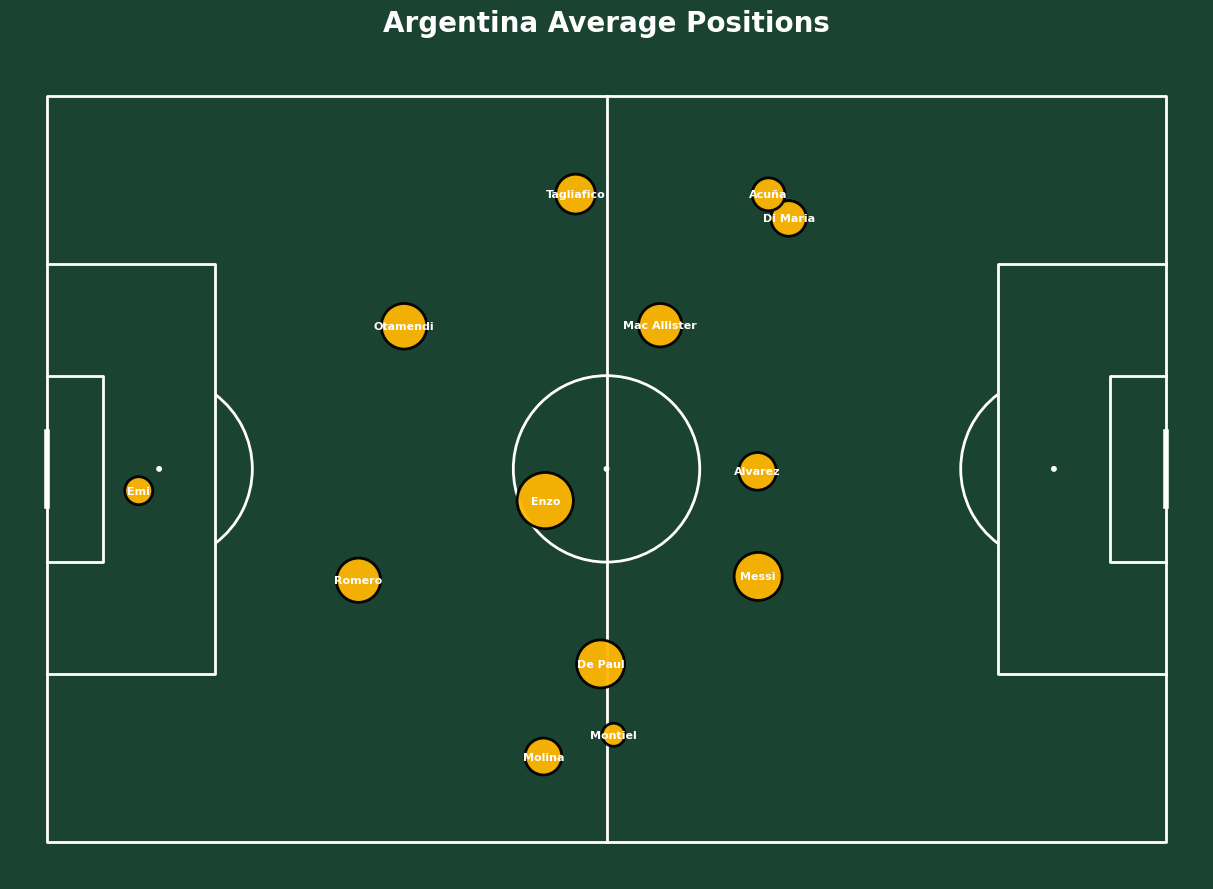

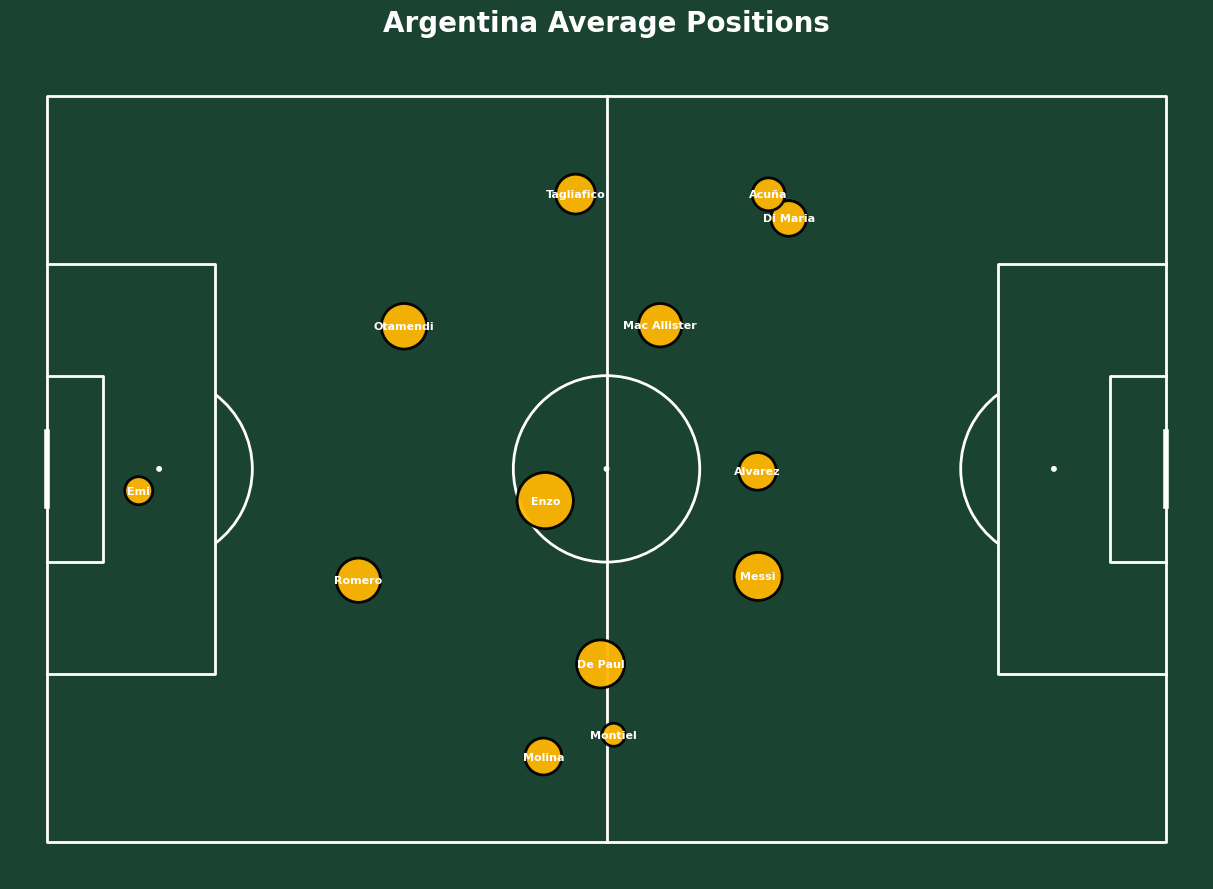

In [40]:
plot_average_positions(events, "Argentina")

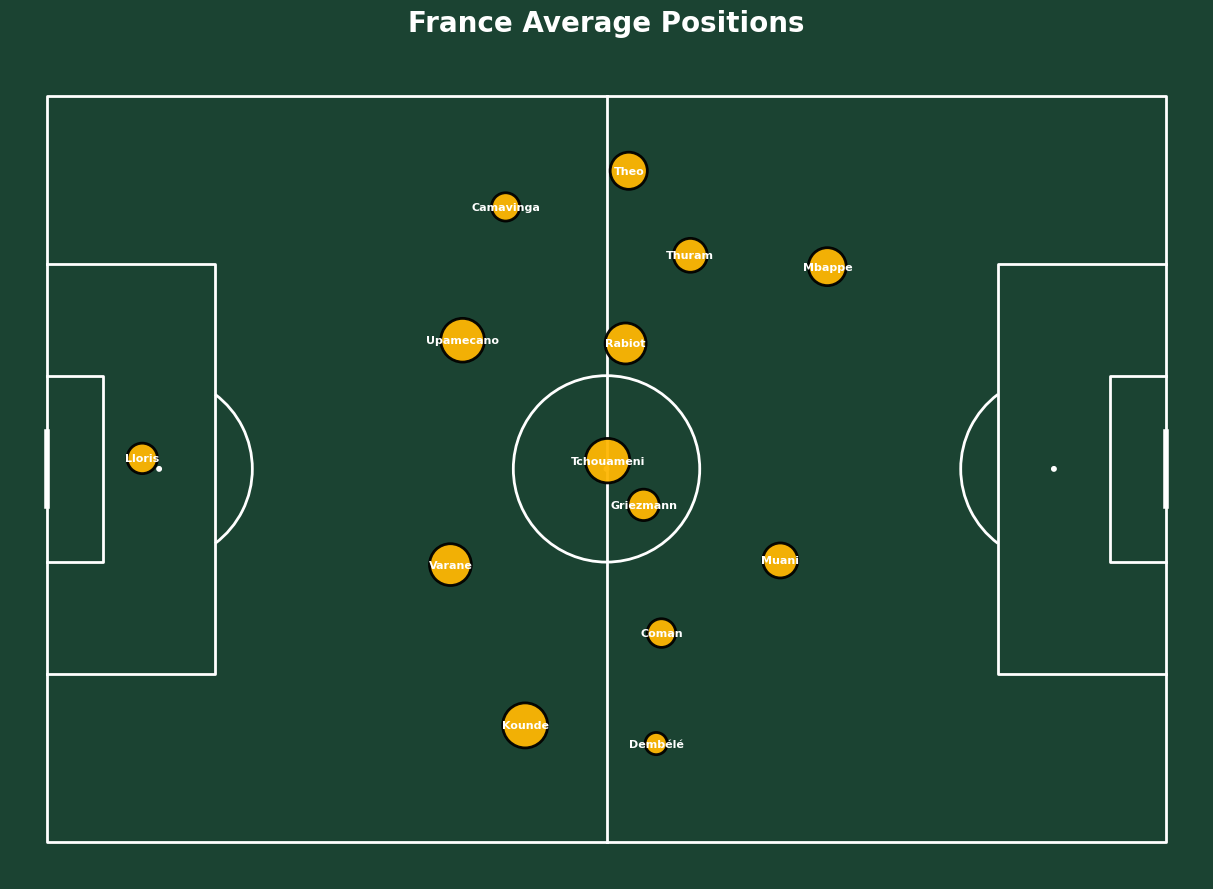

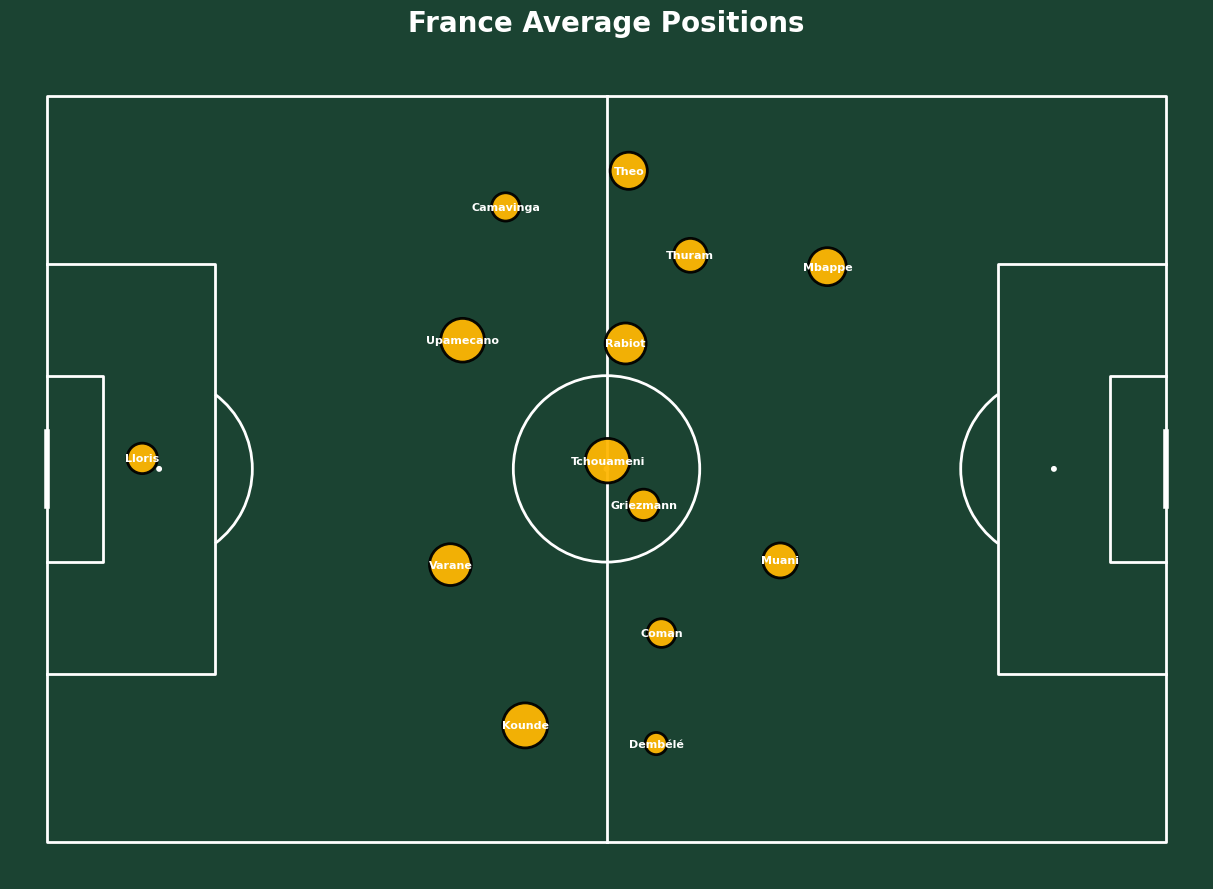

In [41]:
plot_average_positions(events, "France")

In [42]:
passes = events[
    events['type'].apply(
        lambda x: x['name'] if pd.notnull(x) else None
    ) == 'Pass'
]

passes.iloc[0]['pass']

{'recipient': {'id': 10481, 'name': 'Aurélien Djani Tchouaméni'},
 'length': 13.364505,
 'angle': 2.907503,
 'height': {'id': 1, 'name': 'Ground Pass'},
 'end_location': [48.0, 43.2],
 'type': {'id': 65, 'name': 'Kick Off'},
 'body_part': {'id': 38, 'name': 'Left Foot'}}

In [43]:
network = get_pass_network_data(
    events,
    'Argentina'
)

network.sort_values(
    by='pass_count',
    ascending=False
).head(15)

,passer,recipient,pass_count
120,Rodrigo Javier De Paul,Lionel Andrés Messi Cuccittini,18
102,Nicolás Hernán Otamendi,Cristian Gabriel Romero,18
40,Enzo Fernandez,Rodrigo Javier De Paul,17
93,Nahuel Molina Lucero,Rodrigo Javier De Paul,17
12,Cristian Gabriel Romero,Enzo Fernandez,15
109,Nicolás Hernán Otamendi,Nicolás Alejandro Tagliafico,15
94,Nicolás Alejandro Tagliafico,Alexis Mac Allister,14
104,Nicolás Hernán Otamendi,Enzo Fernandez,14
75,Lionel Andrés Messi Cuccittini,Rodrigo Javier De Paul,13
91,Nahuel Molina Lucero,Lionel Andrés Messi Cuccittini,13


In [44]:
network.shape

(133, 3)

In [45]:
network.sort_values(
    by='pass_count',
    ascending=False
).head(15)

,passer,recipient,pass_count
120,Rodrigo Javier De Paul,Lionel Andrés Messi Cuccittini,18
102,Nicolás Hernán Otamendi,Cristian Gabriel Romero,18
40,Enzo Fernandez,Rodrigo Javier De Paul,17
93,Nahuel Molina Lucero,Rodrigo Javier De Paul,17
12,Cristian Gabriel Romero,Enzo Fernandez,15
109,Nicolás Hernán Otamendi,Nicolás Alejandro Tagliafico,15
94,Nicolás Alejandro Tagliafico,Alexis Mac Allister,14
104,Nicolás Hernán Otamendi,Enzo Fernandez,14
75,Lionel Andrés Messi Cuccittini,Rodrigo Javier De Paul,13
91,Nahuel Molina Lucero,Lionel Andrés Messi Cuccittini,13


'Green pitch\nRed player nodes\nYellow connections\nThick lines = more passes\nMessi, Enzo, De Paul becoming the central hubs'

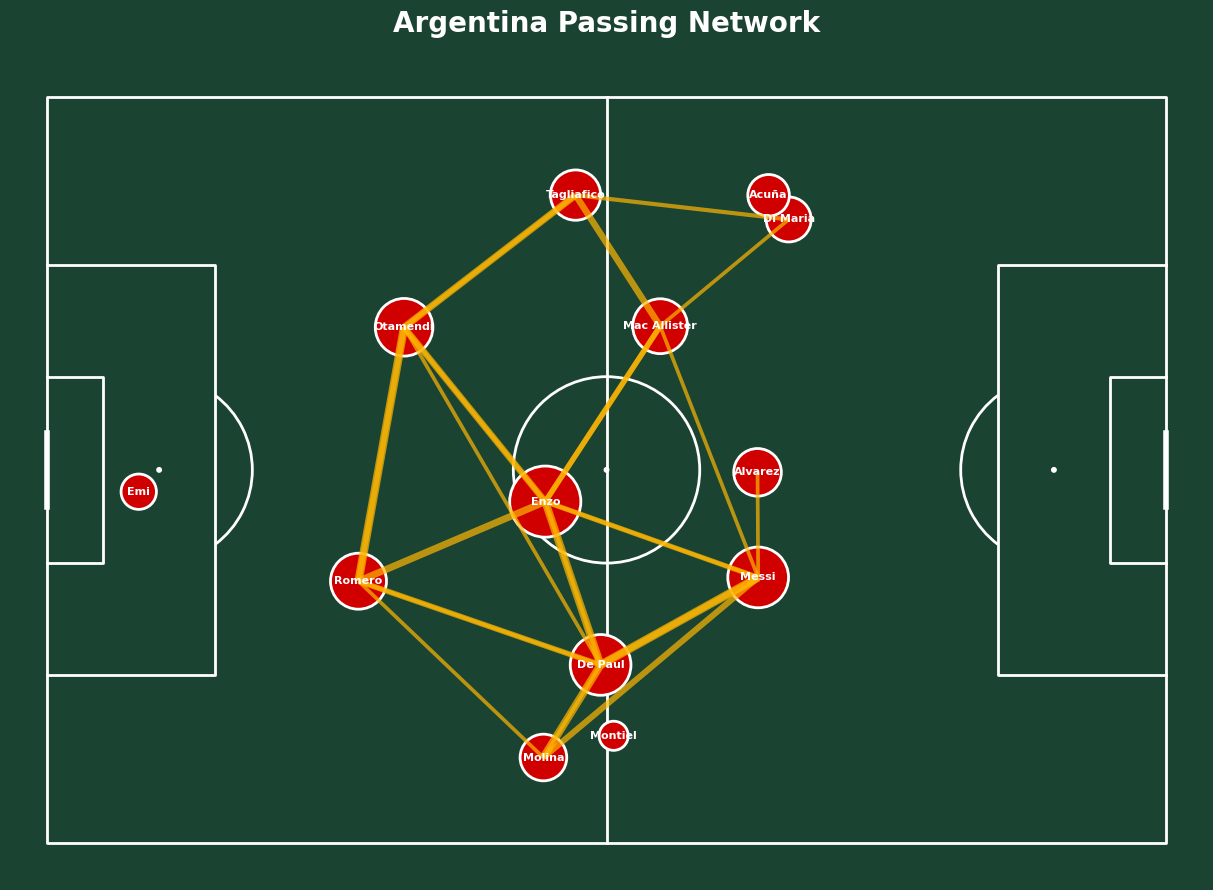

In [46]:
plot_passing_network(
    events,
    "Argentina"
)

'''Green pitch
Red player nodes
Yellow connections
Thick lines = more passes
Messi, Enzo, De Paul becoming the central hubs'''

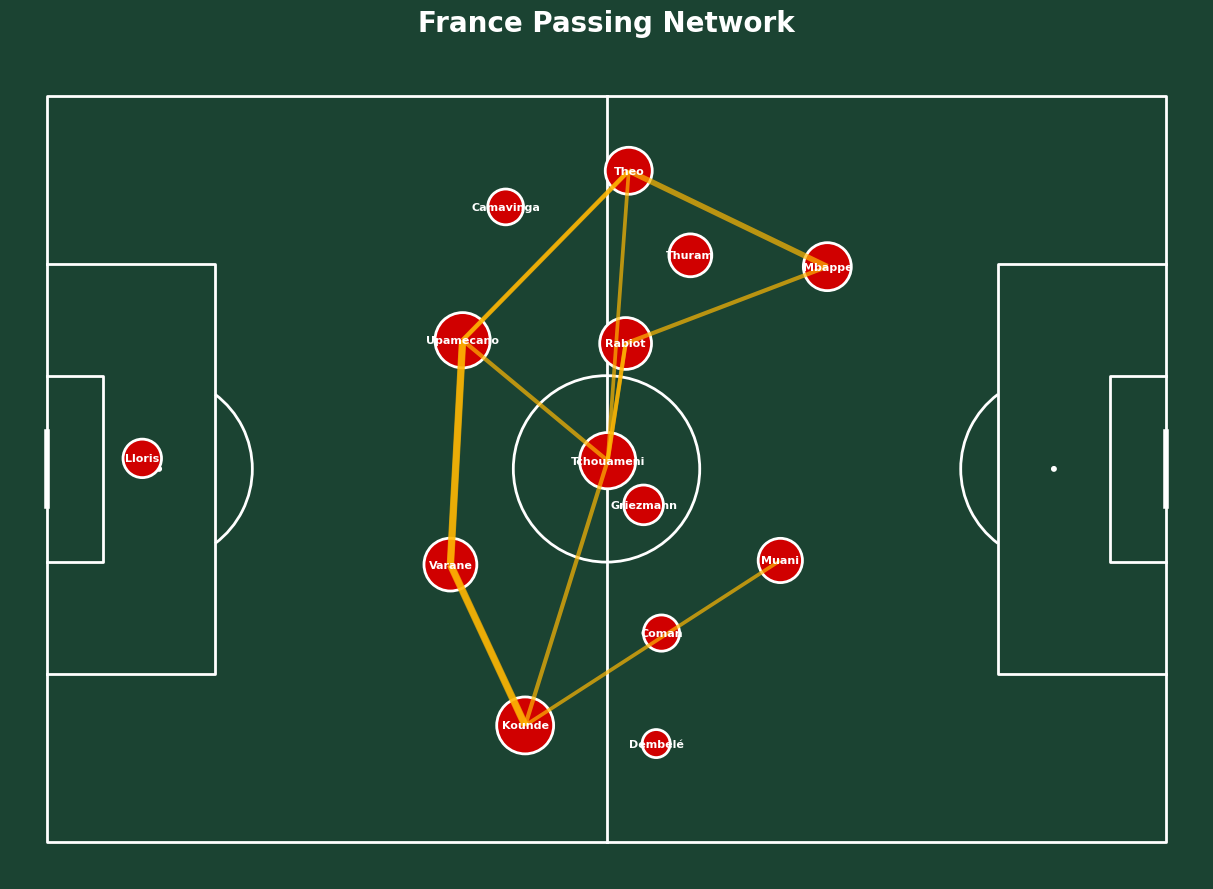

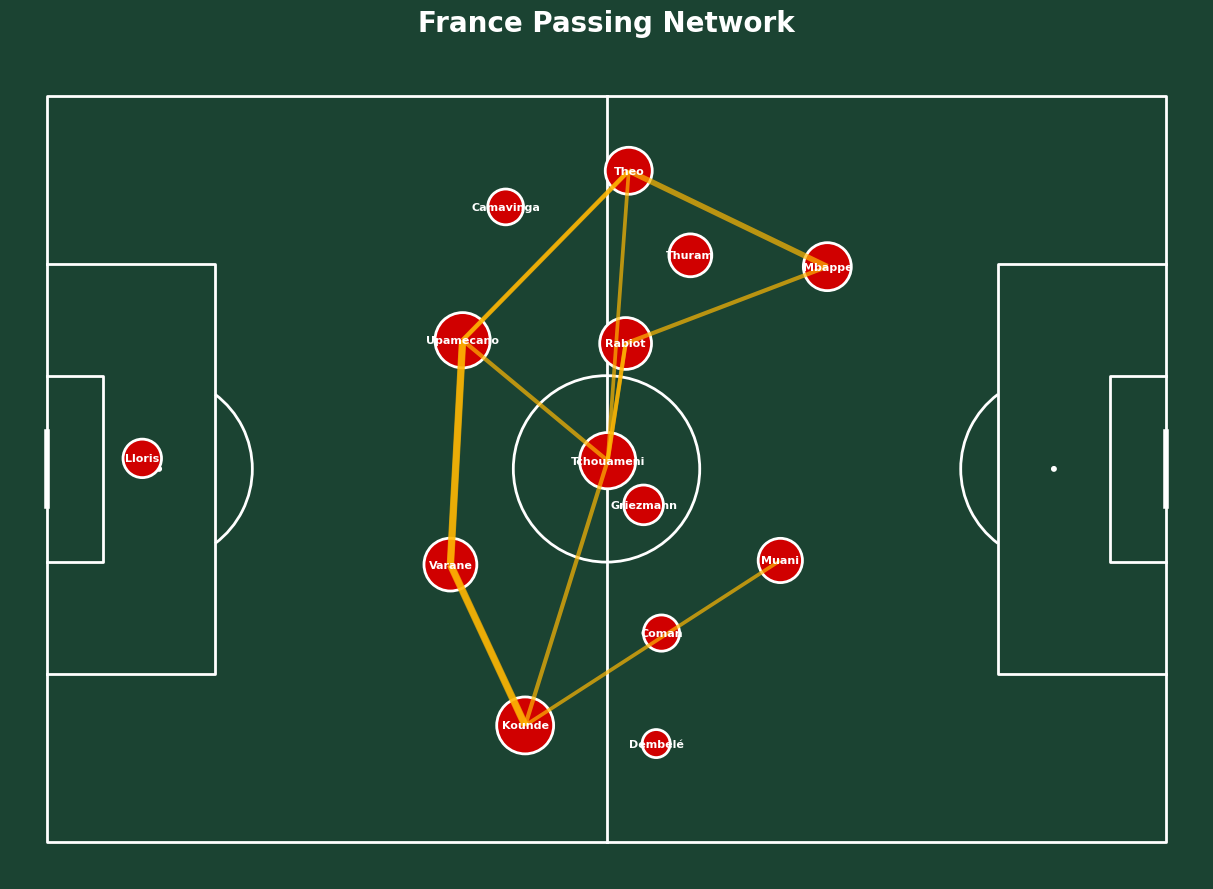

In [47]:
plot_passing_network(
    events,
    "France"
)

In [48]:
get_team_xg(
    events,
    "Argentina"
)

5.89

In [49]:
get_team_xg(
    events,
    "France"
)

5.41

In [50]:
get_player_xg(
    events,
    "Argentina"
)

,player,xG
3,Lionel Andrés Messi Cuccittini,2.24
7,Gonzalo Ariel Montiel,0.80
8,Paulo Bruno Exequiel Dybala,0.78
9,Leandro Daniel Paredes,0.78
6,Lautaro Javier Martínez,0.58
2,Ángel Fabián Di María Hernández,0.41
1,Rodrigo Javier De Paul,0.10
5,Enzo Fernandez,0.07
4,Julián Álvarez,0.06
0,Alexis Mac Allister,0.05


In [51]:
timeline = get_xg_timeline(events)

timeline.head()

,minute,Argentina,France
0,4,0.024542,0.0
1,7,0.087355,0.0
2,16,0.194156,0.0
3,22,0.977656,0.0
4,31,0.988234,0.0


In [52]:
timeline.tail(10)

,minute,Argentina,France
28,120,2.651756,2.778604
29,121,3.435256,2.778604
30,121,3.435256,3.562104
31,122,4.218756,3.562104
32,122,4.218756,3.839618
33,122,4.325306,3.839618
34,123,4.325306,4.623118
35,124,5.108806,4.623118
36,125,5.108806,5.406618
37,125,5.892306,5.406618


In [53]:
print(get_team_xg(events, "Argentina"))
print(get_team_xg(events, "France"))

5.89
5.41


In [54]:
timeline = get_xg_timeline(events)

timeline.tail()

,minute,Argentina,France
33,122,4.325306,3.839618
34,123,4.325306,4.623118
35,124,5.108806,4.623118
36,125,5.108806,5.406618
37,125,5.892306,5.406618


In [55]:
shots = events[
    events['type'].apply(
        lambda x: x['name'] if pd.notnull(x) else None
    ) == 'Shot'
]

shots.groupby(
    shots['team'].apply(lambda x: x['name'])
).size()

team
Argentina    24
France       14
dtype: int64

In [56]:
shots[['minute', 'team', 'player', 'shot']]

,minute,team,player,shot
191,4,"{'id': 779, 'name': 'Argentina'}","{'id': 27886, 'name': 'Alexis Mac Allister'}","{'statsbomb_xg': 0.024542088, 'end_location': ..."
339,7,"{'id': 779, 'name': 'Argentina'}","{'id': 7797, 'name': 'Rodrigo Javier De Paul'}","{'statsbomb_xg': 0.062813334, 'end_location': ..."
601,16,"{'id': 779, 'name': 'Argentina'}","{'id': 2995, 'name': 'Ángel Fabián Di María He...","{'statsbomb_xg': 0.106800534, 'end_location': ..."
770,22,"{'id': 779, 'name': 'Argentina'}","{'id': 5503, 'name': 'Lionel Andrés Messi Cucc...","{'statsbomb_xg': 0.7835000000000001, 'end_loca..."
978,31,"{'id': 779, 'name': 'Argentina'}","{'id': 27886, 'name': 'Alexis Mac Allister'}","{'statsbomb_xg': 0.010577817000000002, 'end_lo..."
1177,35,"{'id': 779, 'name': 'Argentina'}","{'id': 2995, 'name': 'Ángel Fabián Di María He...","{'statsbomb_xg': 0.30340916, 'end_location': [..."
1915,48,"{'id': 779, 'name': 'Argentina'}","{'id': 7797, 'name': 'Rodrigo Javier De Paul'}","{'statsbomb_xg': 0.040216275, 'end_location': ..."
2203,58,"{'id': 779, 'name': 'Argentina'}","{'id': 29560, 'name': 'Julián Álvarez'}","{'one_on_one': True, 'statsbomb_xg': 0.0595337..."
2234,59,"{'id': 779, 'name': 'Argentina'}","{'id': 5503, 'name': 'Lionel Andrés Messi Cucc...","{'statsbomb_xg': 0.11555985, 'end_location': [..."
2516,67,"{'id': 771, 'name': 'France'}","{'id': 22097, 'name': 'Randal Kolo Muani'}","{'statsbomb_xg': 0.09618377, 'end_location': [..."


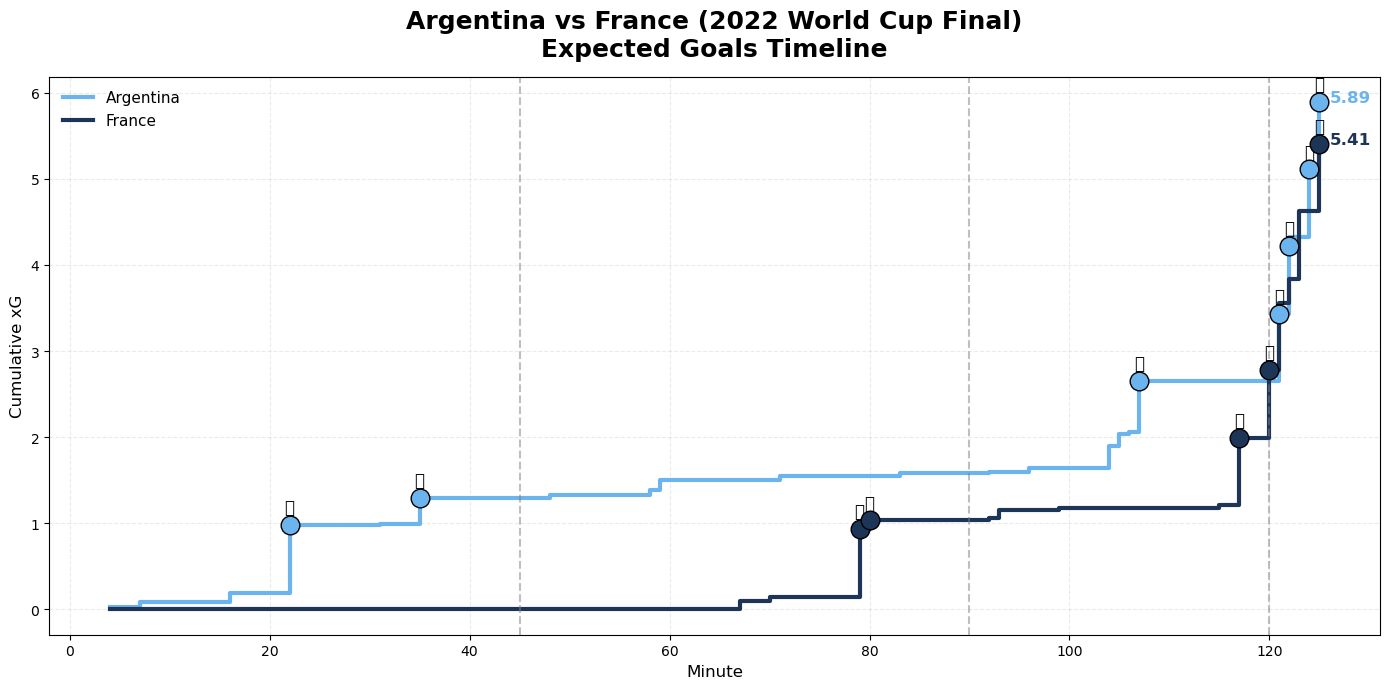

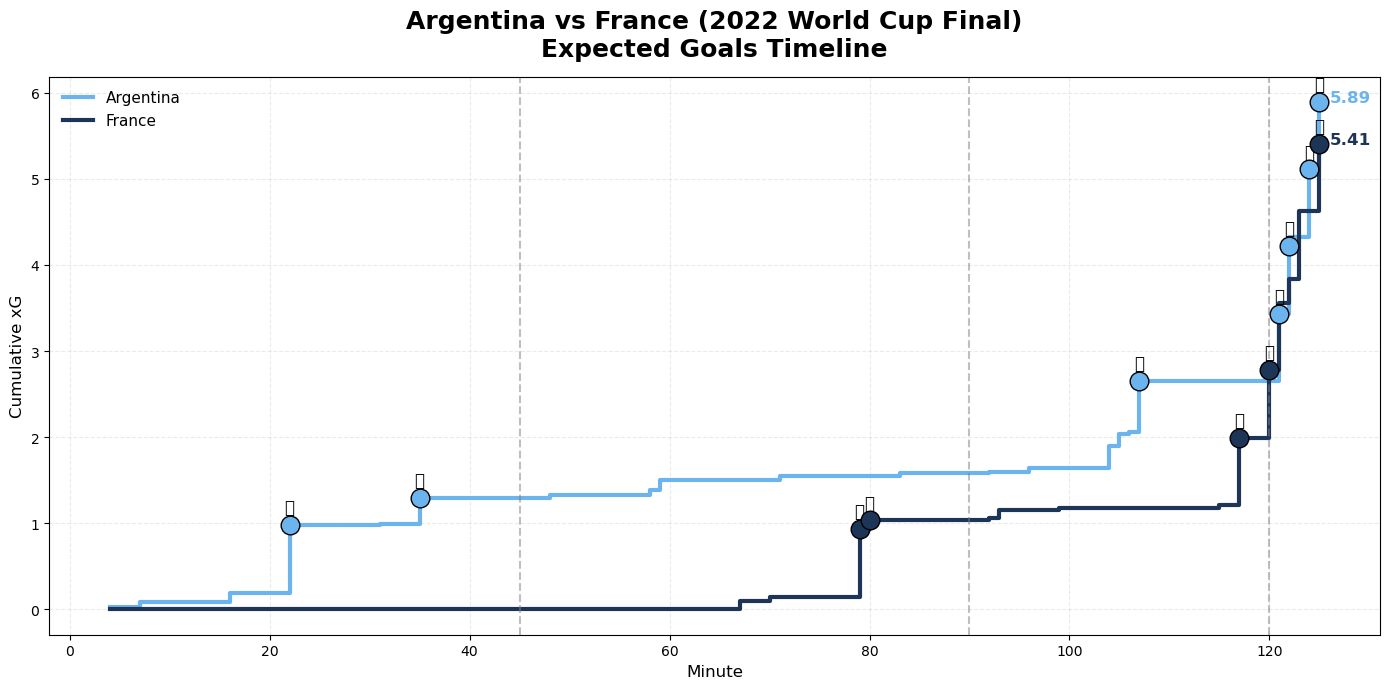

In [57]:
plot_xg_timeline(events)

In [58]:
compare_teams_with_xg(
    events,
    'Argentina',
    'France'
)

,Metric,Argentina,France
0,Passes,693.00,570.00
1,Shots,24.00,14.00
2,Carries,513.00,427.00
3,Pressures,167.00,194.00
4,Ball Recoveries,59.00,56.00
5,xG,5.89,5.41


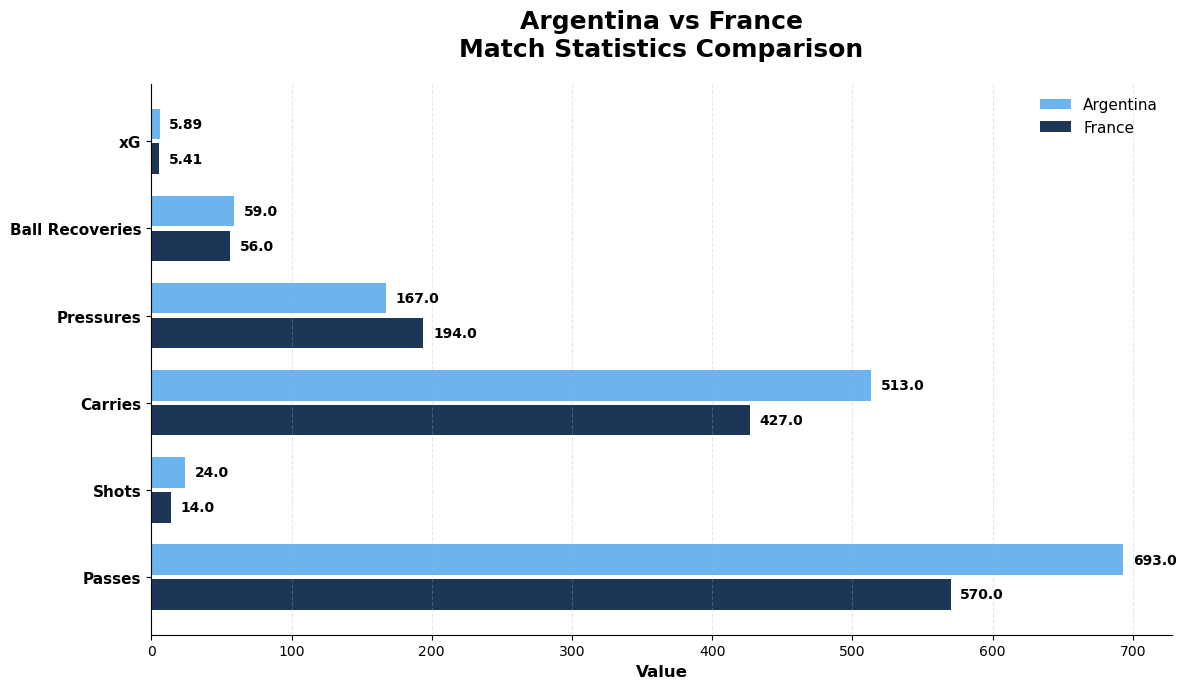

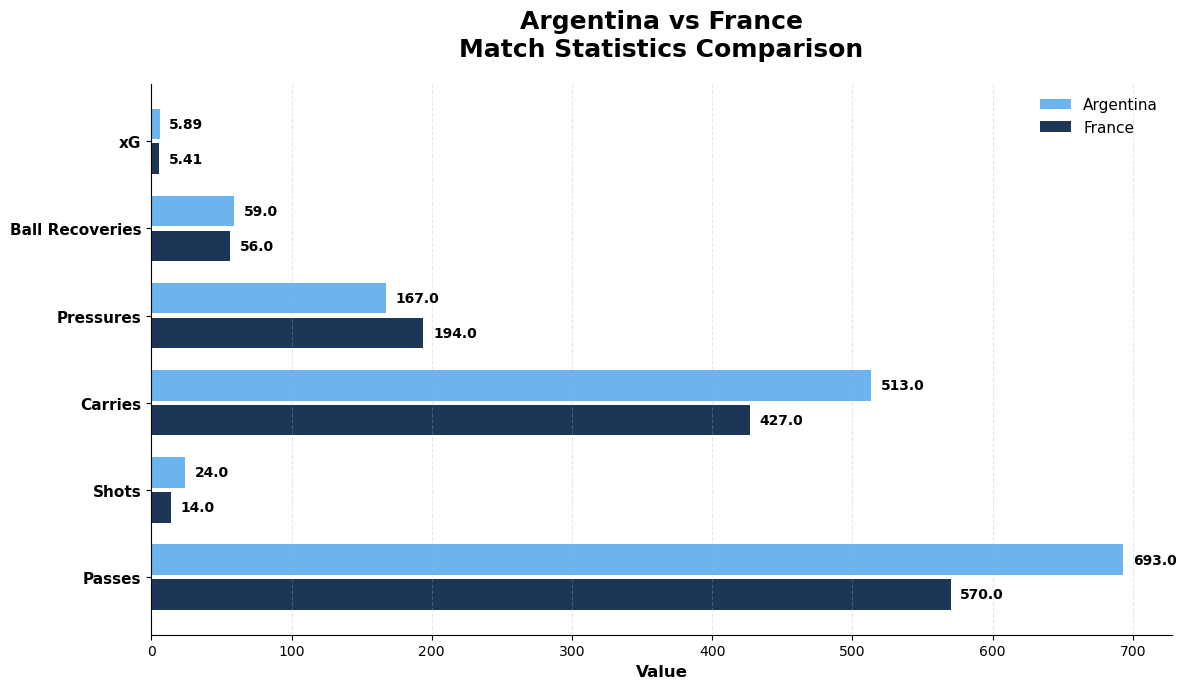

In [59]:
plot_team_comparison(
    events,
    'Argentina',
    'France'
)

In [60]:
get_player_radar_stats(
    events,
    'Lionel Andrés Messi Cuccittini'
)

{'Passes': 60,
 'Shots': 6,
 'Carries': 53,
 'Dribbles': 3,
 'Pressures': 17,
 'Recoveries': 7}

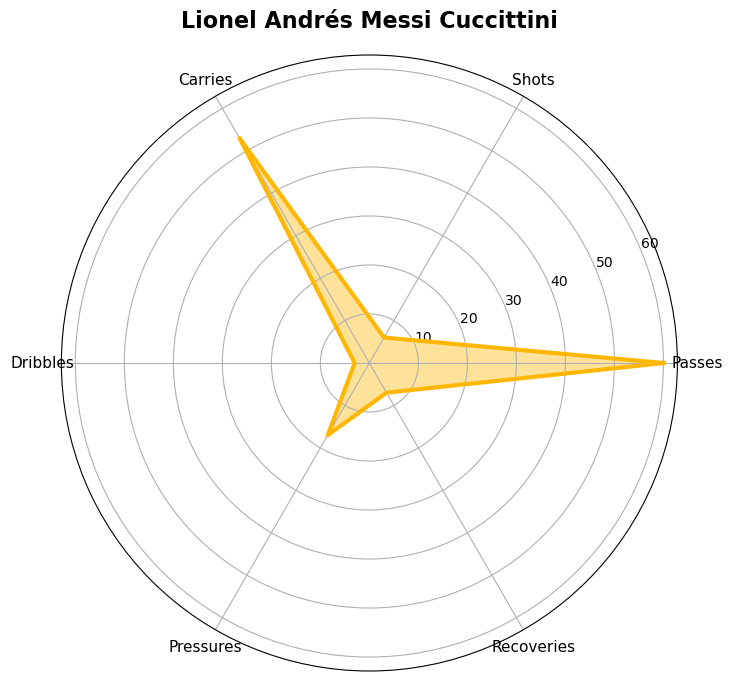

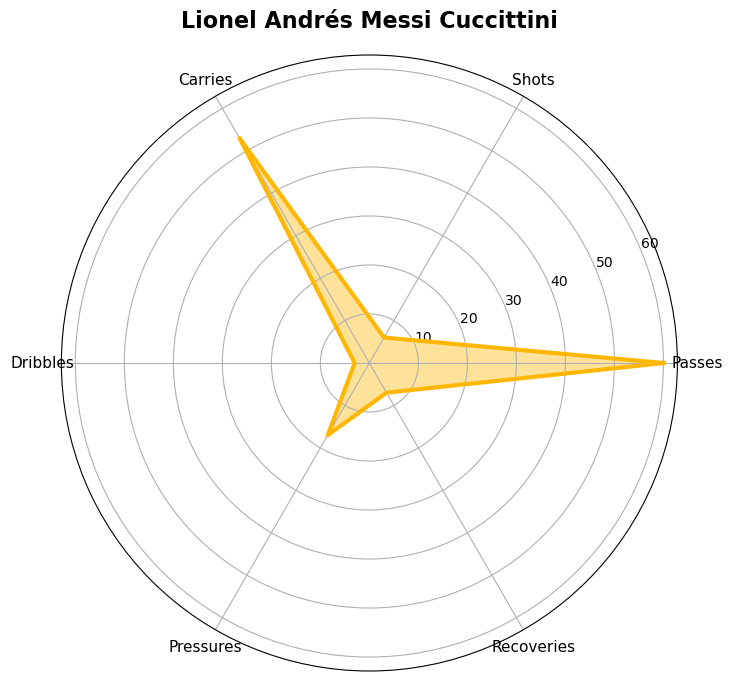

In [61]:
plot_player_radar(
    events,
    'Lionel Andrés Messi Cuccittini'
)

In [62]:
get_normalized_radar_stats(
    events,
    'Lionel Andrés Messi Cuccittini'
)

{'Passes': np.float64(63.8),
 'Shots': np.float64(85.7),
 'Carries': np.float64(72.6),
 'Dribbles': np.float64(27.3),
 'Pressures': np.float64(56.7),
 'Recoveries': np.float64(70.0)}

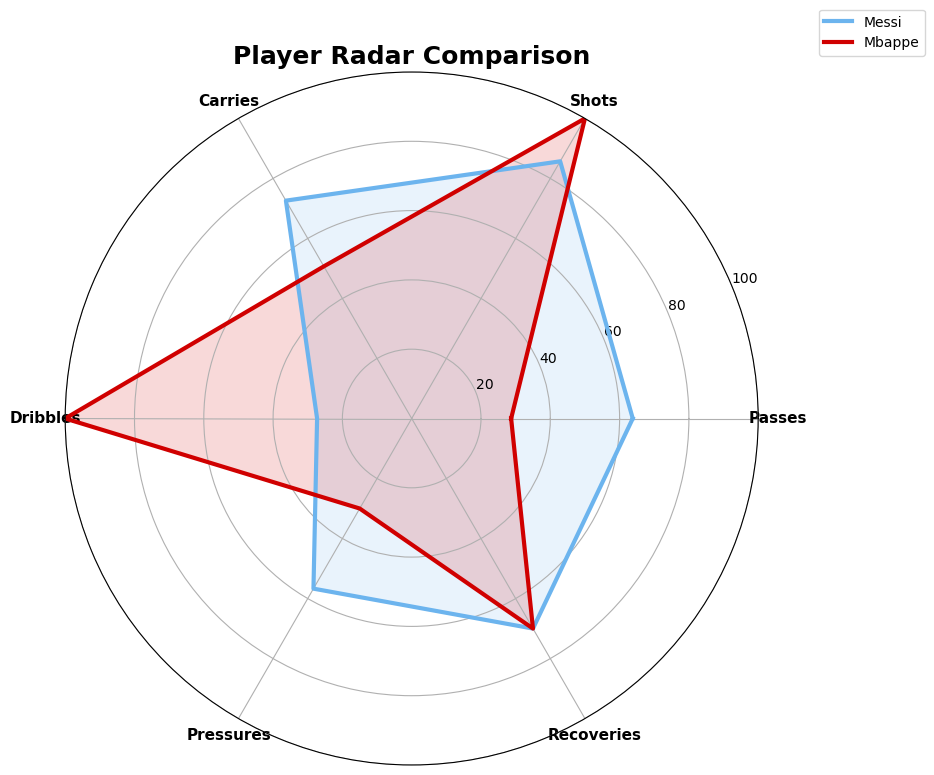

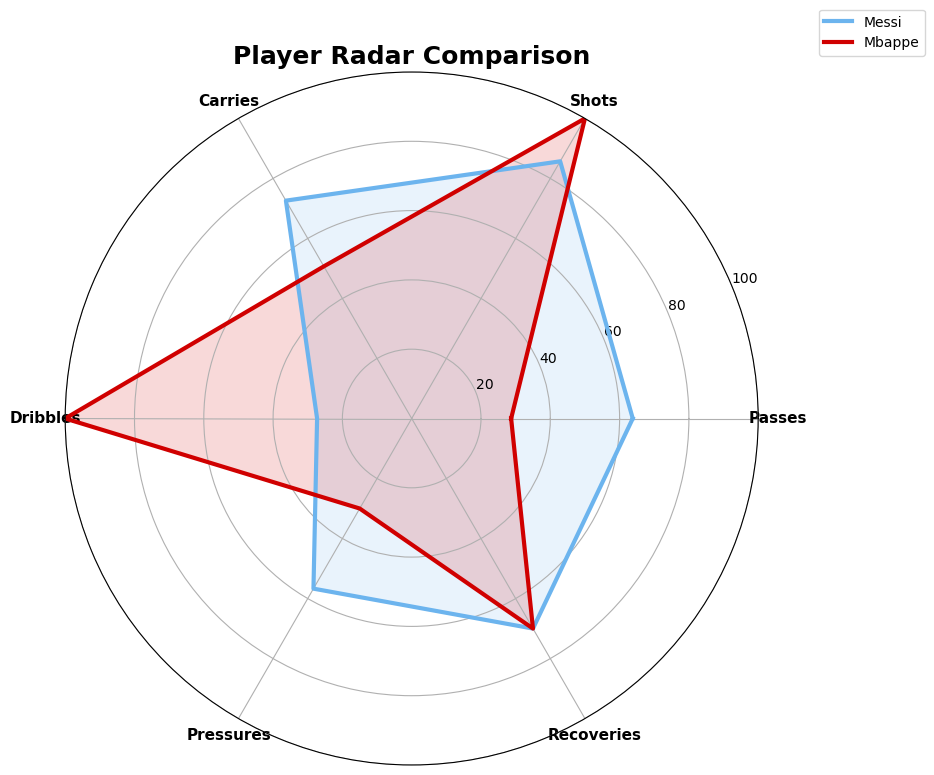

In [63]:
compare_player_radars(
    events,
    'Lionel Andrés Messi Cuccittini',
    'Kylian Mbappé Lottin'
)

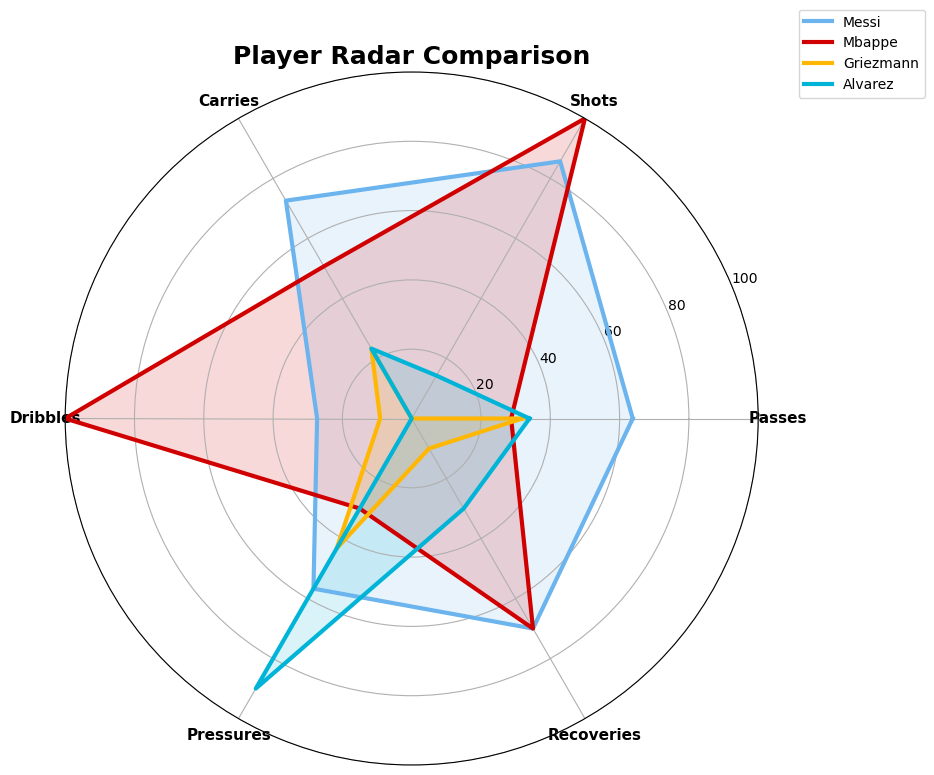

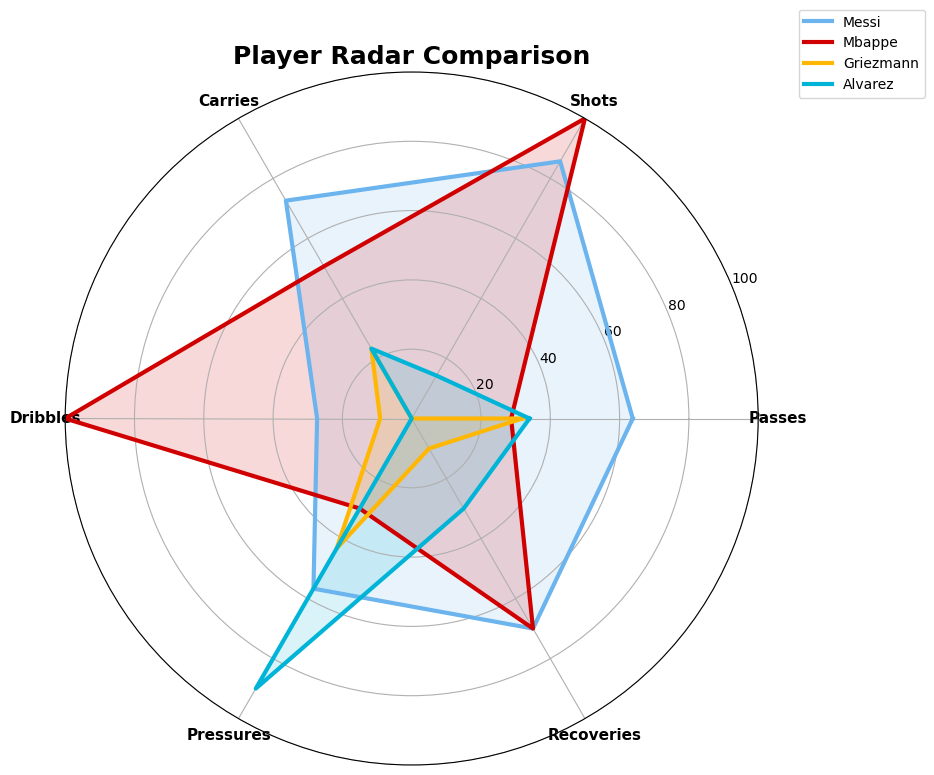

In [64]:
compare_player_radars(
    events,
    "Lionel Andrés Messi Cuccittini",
    "Kylian Mbappé Lottin",
    "Antoine Griezmann",
    "Julián Álvarez"
)

In [65]:
pass_network = get_pass_network(
    events,
    'Argentina'
)

pass_network.sort_values(
    'pass_count',
    ascending=False
).head(15)

,passer,recipient,pass_count
120,Rodrigo Javier De Paul,Lionel Andrés Messi Cuccittini,18
102,Nicolás Hernán Otamendi,Cristian Gabriel Romero,18
40,Enzo Fernandez,Rodrigo Javier De Paul,17
93,Nahuel Molina Lucero,Rodrigo Javier De Paul,17
12,Cristian Gabriel Romero,Enzo Fernandez,15
109,Nicolás Hernán Otamendi,Nicolás Alejandro Tagliafico,15
94,Nicolás Alejandro Tagliafico,Alexis Mac Allister,14
104,Nicolás Hernán Otamendi,Enzo Fernandez,14
75,Lionel Andrés Messi Cuccittini,Rodrigo Javier De Paul,13
91,Nahuel Molina Lucero,Lionel Andrés Messi Cuccittini,13


'🔴 Circle size = touches\n🟡 Line thickness = pass frequency\n⚪ Names inside circles\n🟢 Green pitch'

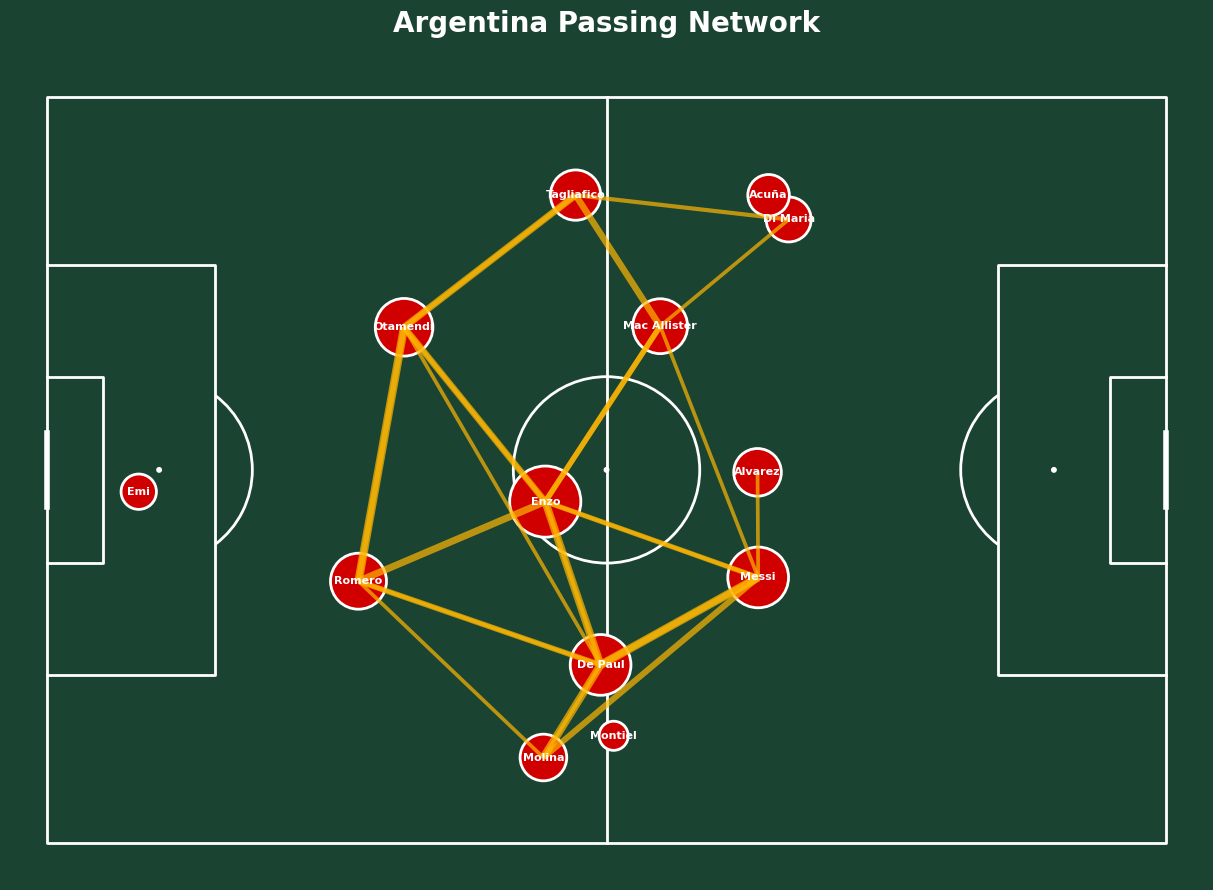

In [66]:
plot_passing_network(
    events,
    'Argentina'
)

'''🔴 Circle size = touches
🟡 Line thickness = pass frequency
⚪ Names inside circles
🟢 Green pitch'''

'🔴 Circle size = touches\n🟡 Line thickness = pass frequency\n⚪ Names inside circles\n🟢 Green pitch'

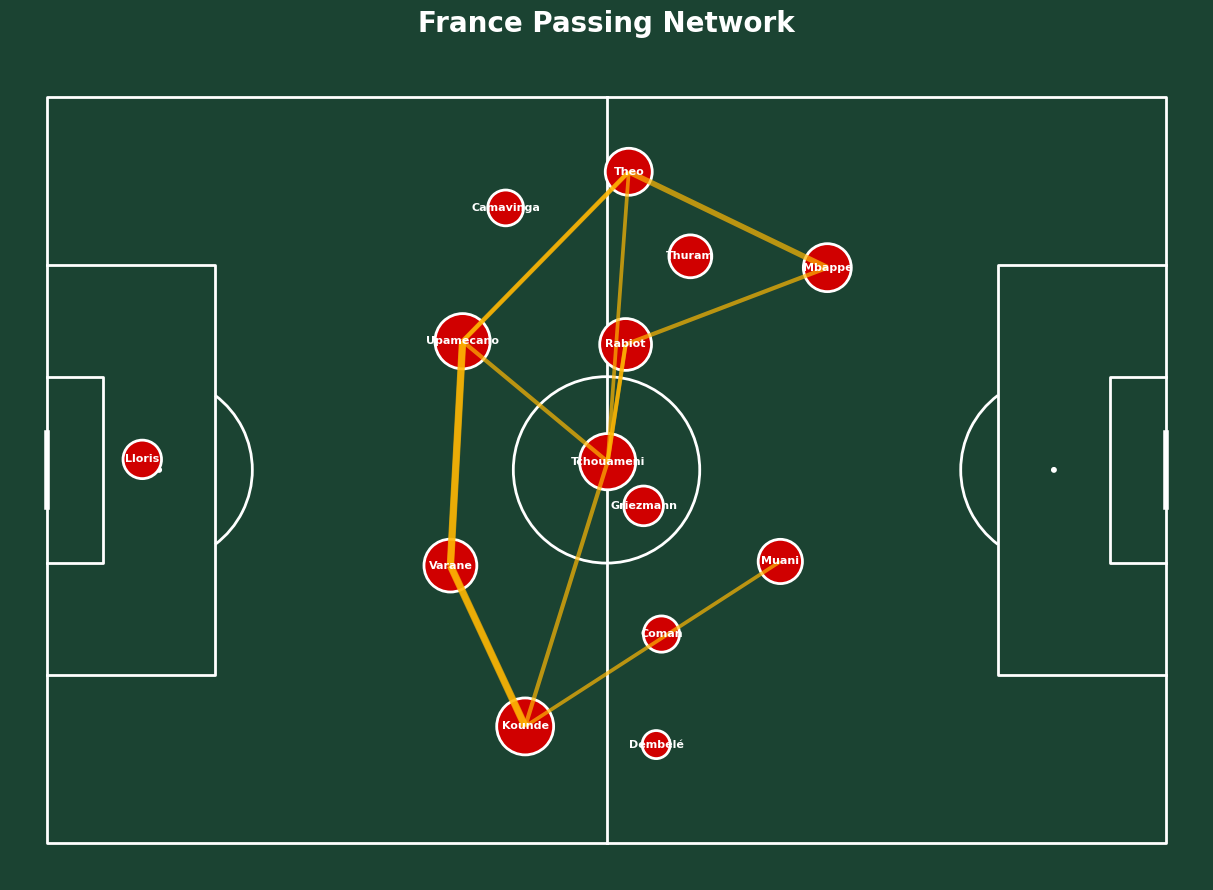

In [67]:
plot_passing_network(
    events,
    'France'
)

'''🔴 Circle size = touches
🟡 Line thickness = pass frequency
⚪ Names inside circles
🟢 Green pitch'''

In [68]:
!pip install fastapi uvicorn pandas mplsoccer

In [69]:
import fastapi

In [70]:
events.columns.tolist()

['id',
 'index',
 'period',
 'timestamp',
 'minute',
 'second',
 'type',
 'possession',
 'possession_team',
 'play_pattern',
 'team',
 'duration',
 'tactics',
 'related_events',
 'player',
 'position',
 'location',
 'pass',
 'carry',
 'ball_receipt',
 'under_pressure',
 'off_camera',
 'counterpress',
 'block',
 'foul_won',
 'out',
 'clearance',
 'duel',
 'interception',
 'dribble',
 'shot',
 'goalkeeper',
 'ball_recovery',
 'foul_committed',
 'substitution',
 '50_50',
 'bad_behaviour']

In [71]:
print(events.columns.tolist())

['id', 'index', 'period', 'timestamp', 'minute', 'second', 'type', 'possession', 'possession_team', 'play_pattern', 'team', 'duration', 'tactics', 'related_events', 'player', 'position', 'location', 'pass', 'carry', 'ball_receipt', 'under_pressure', 'off_camera', 'counterpress', 'block', 'foul_won', 'out', 'clearance', 'duel', 'interception', 'dribble', 'shot', 'goalkeeper', 'ball_recovery', 'foul_committed', 'substitution', '50_50', 'bad_behaviour']
